In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

In [2]:
spotify = pd.read_csv("spotify_merged_clean.csv")

In [3]:
continuous_features = [
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo'
]

spotify[continuous_features] = StandardScaler().fit_transform(spotify[continuous_features])

spotify.drop(columns=['key', 'mode'], inplace=True)

# If you want a clustering input table, it can now be taken directly from spotify.
X_for_clustering = spotify[continuous_features].copy()

spotify[continuous_features]

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,1.868896,-1.123959,-0.335257,0.919773,-0.678968,-0.512296,-0.311653,-0.160929,-0.605689
1,0.592912,-0.364169,-1.029071,-0.417897,-0.909587,0.052991,-0.538150,-1.418237,-0.063065
2,0.553037,0.493659,0.944242,0.840984,-0.732788,-0.521856,-0.688270,1.418466,1.355952
3,-0.358380,-0.891120,-1.098452,-0.567597,-0.910132,1.764826,-0.640337,-0.929284,0.276147
4,0.570126,-1.013667,-0.380699,-0.615746,-0.050149,-0.484697,-0.655612,0.359068,-0.842090
...,...,...,...,...,...,...,...,...,...
106003,0.382146,0.755092,-0.657008,-0.474801,-0.084172,2.438127,-0.609786,-1.255252,0.107221
106004,2.170802,-0.188518,0.399132,0.753440,-0.704950,-0.521837,0.004389,0.673395,0.276793
106005,-0.705858,-0.445867,0.351863,-0.585981,1.298427,-0.520496,-0.517080,0.712201,0.692663
106006,-1.816647,1.257534,0.264629,-0.037081,-0.913043,-0.501847,0.868237,-1.045701,1.737234


In [4]:
GENRE_MAPPING = {
    # Rock
    "rock": "Rock",
    "alt-rock": "Rock",
    "album rock": "Rock",
    "classic rock": "Rock",
    "hard-rock": "Rock",
    "hard rock": "Rock",
    "psych-rock": "Rock",
    "rock-n-roll": "Rock",
    "rockabilly": "Rock",
    "grunge": "Rock",
    "j-rock": "Rock",
    "permanent wave": "Rock",

    # Punk / Alternative
    "alternative": "Alternative",
    "indie": "Alternative",
    "indie-pop": "Alternative",
    "indie poptimism": "Alternative",
    "emo": "Alternative",
    "goth": "Alternative",
    "punk": "Alternative",
    "punk-rock": "Alternative",

    # Metal
    "metal": "Metal",
    "heavy-metal": "Metal",
    "death-metal": "Metal",
    "black-metal": "Metal",
    "metalcore": "Metal",
    "grindcore": "Metal",
    "groove": "Metal",
    "hardcore": "Metal",

    # Pop
    "pop": "Pop",
    "dance pop": "Pop",
    "electropop": "Pop",
    "post-teen pop": "Pop",
    "power-pop": "Pop",
    "synth-pop": "Pop",
    "j-pop": "Pop",
    "k-pop": "Pop",
    "cantopop": "Pop",
    "mandopop": "Pop",
    "latin pop": "Pop",
    "hip pop": "Pop",

    # Hip Hop / R&B
    "rap": "Hip-Hop/R&B",
    "hip-hop": "Hip-Hop/R&B",
    "hip hop": "Hip-Hop/R&B",
    "r&b": "Hip-Hop/R&B",
    "r-n-b": "Hip-Hop/R&B",
    "neo soul": "Hip-Hop/R&B",
    "new jack swing": "Hip-Hop/R&B",
    "urban contemporary": "Hip-Hop/R&B",
    "southern hip hop": "Hip-Hop/R&B",
    "latin hip hop": "Hip-Hop/R&B",
    "gangster rap": "Hip-Hop/R&B",
    "trap": "Hip-Hop/R&B",
    "soul": "Hip-Hop/R&B",

    # Electronic
    "edm": "Electronic",
    "electronic": "Electronic",
    "electro": "Electronic",
    "house": "Electronic",
    "deep-house": "Electronic",
    "chicago-house": "Electronic",
    "progressive-house": "Electronic",
    "electro house": "Electronic",
    "progressive electro house": "Electronic",
    "techno": "Electronic",
    "minimal-techno": "Electronic",
    "detroit-techno": "Electronic",
    "trance": "Electronic",
    "dubstep": "Electronic",
    "drum-and-bass": "Electronic",
    "breakbeat": "Electronic",
    "garage": "Electronic",
    "idm": "Electronic",
    "club": "Electronic",
    "dance": "Electronic",
    "hardstyle": "Electronic",
    "big room": "Electronic",
    "pop edm": "Electronic",
    "disco": "Electronic",
    "industrial": "Electronic",

    # Ambient / Chill
    "ambient": "Ambient/Chill",
    "chill": "Ambient/Chill",
    "new-age": "Ambient/Chill",
    "sleep": "Ambient/Chill",
    "study": "Ambient/Chill",
    "trip-hop": "Ambient/Chill",
    "tropical": "Ambient/Chill",

    # Folk / Country
    "folk": "Folk/Country",
    "acoustic": "Folk/Country",
    "country": "Folk/Country",
    "bluegrass": "Folk/Country",
    "honky-tonk": "Folk/Country",
    "singer-songwriter": "Folk/Country",

    # Jazz / Blues
    "jazz": "Jazz/Blues",
    "blues": "Jazz/Blues",
    "gospel": "Jazz/Blues",
    "funk": "Jazz/Blues",

    # Reggae
    "reggae": "Reggae",
    "dancehall": "Reggae",
    "dub": "Reggae",
    "ska": "Reggae",

    # Latin
    "latin": "Latin",
    "latino": "Latin",
    "reggaeton": "Latin",
    "salsa": "Latin",
    "tango": "Latin",
    "samba": "Latin",
    "pagode": "Latin",
    "mpb": "Latin",
    "sertanejo": "Latin",
    "forro": "Latin",
    "brazil": "Latin",

    # World
    "afrobeat": "World",
    "indian": "World",
    "iranian": "World",
    "turkish": "World",
    "malay": "World",
    "world-music": "World",

    # Classical
    "classical": "Classical",
    "opera": "Classical",
    "piano": "Classical",

    # Soundtracks
    "anime": "Soundtrack",
    "disney": "Soundtrack",
    "show-tunes": "Soundtrack",
    "pop-film": "Soundtrack",

    # Kids
    "children": "Kids",
    "kids": "Kids",

    # Spoken
    "comedy": "Spoken",

    # Mood
    "happy": "Mood",
    "sad": "Mood",
    "party": "Mood",
    "romance": "Mood",

    # Instrumental
    "guitar": "Instrumental",

    # Regional labels
    "british": "Regional",
    "french": "Regional",
    "german": "Regional",
    "spanish": "Regional",
    "swedish": "Regional",
    "j-idol": "Regional",
    "j-dance": "Regional",
}

In [5]:
super_genres = {genre: [] for genre in GENRE_MAPPING.values()}

for name, super_genre in GENRE_MAPPING.items():
    super_genres[super_genre].append(name)

for genre in super_genres:
    print(f"{genre:15} \tSub-genres: {super_genres[genre]}")

Rock            	Sub-genres: ['rock', 'alt-rock', 'album rock', 'classic rock', 'hard-rock', 'hard rock', 'psych-rock', 'rock-n-roll', 'rockabilly', 'grunge', 'j-rock', 'permanent wave']
Alternative     	Sub-genres: ['alternative', 'indie', 'indie-pop', 'indie poptimism', 'emo', 'goth', 'punk', 'punk-rock']
Metal           	Sub-genres: ['metal', 'heavy-metal', 'death-metal', 'black-metal', 'metalcore', 'grindcore', 'groove', 'hardcore']
Pop             	Sub-genres: ['pop', 'dance pop', 'electropop', 'post-teen pop', 'power-pop', 'synth-pop', 'j-pop', 'k-pop', 'cantopop', 'mandopop', 'latin pop', 'hip pop']
Hip-Hop/R&B     	Sub-genres: ['rap', 'hip-hop', 'hip hop', 'r&b', 'r-n-b', 'neo soul', 'new jack swing', 'urban contemporary', 'southern hip hop', 'latin hip hop', 'gangster rap', 'trap', 'soul']
Electronic      	Sub-genres: ['edm', 'electronic', 'electro', 'house', 'deep-house', 'chicago-house', 'progressive-house', 'electro house', 'progressive electro house', 'techno', 'minimal-te

In [6]:
vc = spotify['macro_genre'].value_counts()
print(vc)

macro_genre
Electronic       19481
Latin            11268
Hip-Hop/R&B      10289
Pop               9431
Rock              7936
Metal             6035
Ambient/Chill     5602
Regional          5499
World             5327
Folk/Country      4492
Soundtrack        3553
Alternative       3365
Mood              3003
Reggae            2600
Classical         2256
Jazz/Blues        2189
Kids              1827
Spoken             987
Instrumental       868
Name: count, dtype: int64


## Dimensionality reduction through PCA

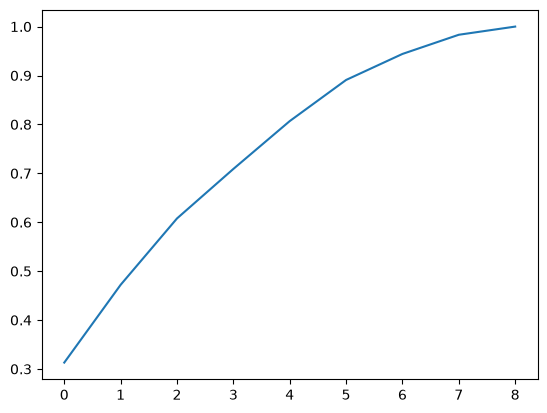

In [7]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

pca = PCA()
X_pca = pca.fit_transform(X_for_clustering)

plt.plot(np.cumsum(pca.explained_variance_ratio_))

In [8]:
pca = PCA(n_components=5, random_state=42)

X_pca = pca.fit_transform(X_for_clustering)

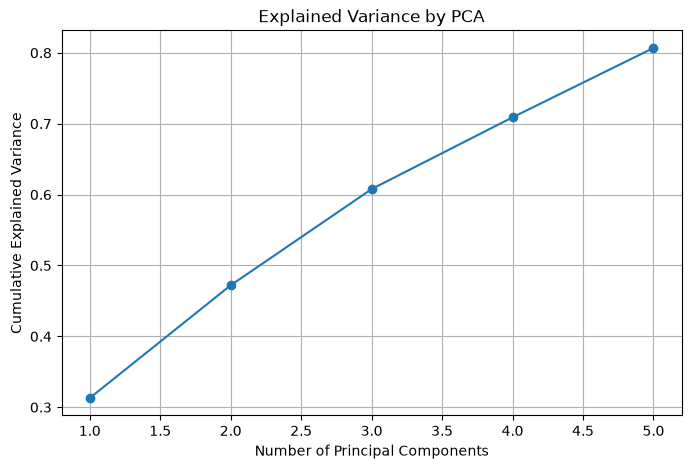

In [9]:
explained = pca.explained_variance_ratio_
cum_explained = np.cumsum(explained)

plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(cum_explained)+1),
    cum_explained,
    marker="o"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance by PCA")

plt.grid(True)

plt.show()

In [10]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)],
    index=X_for_clustering.columns
)

display(loadings)

,PC1,PC2,PC3,PC4,PC5
danceability,0.253995,0.564682,-0.143002,-0.249104,0.265659
energy,0.508426,-0.286040,0.010743,-0.175680,-0.010534
loudness,0.518883,-0.094263,-0.040143,-0.021306,-0.180716
speechiness,0.103225,0.127855,0.620677,-0.184337,0.595141
acousticness,-0.441019,0.293679,0.198713,0.315383,-0.030096
instrumentalness,-0.279726,-0.310383,-0.211432,-0.433146,0.459052
liveness,0.075919,-0.212743,0.696922,0.057889,-0.225641
valence,0.289683,0.515600,-0.032473,0.204871,0.013820
tempo,0.186201,-0.283540,-0.147099,0.735013,0.528890


Let's visualize the data

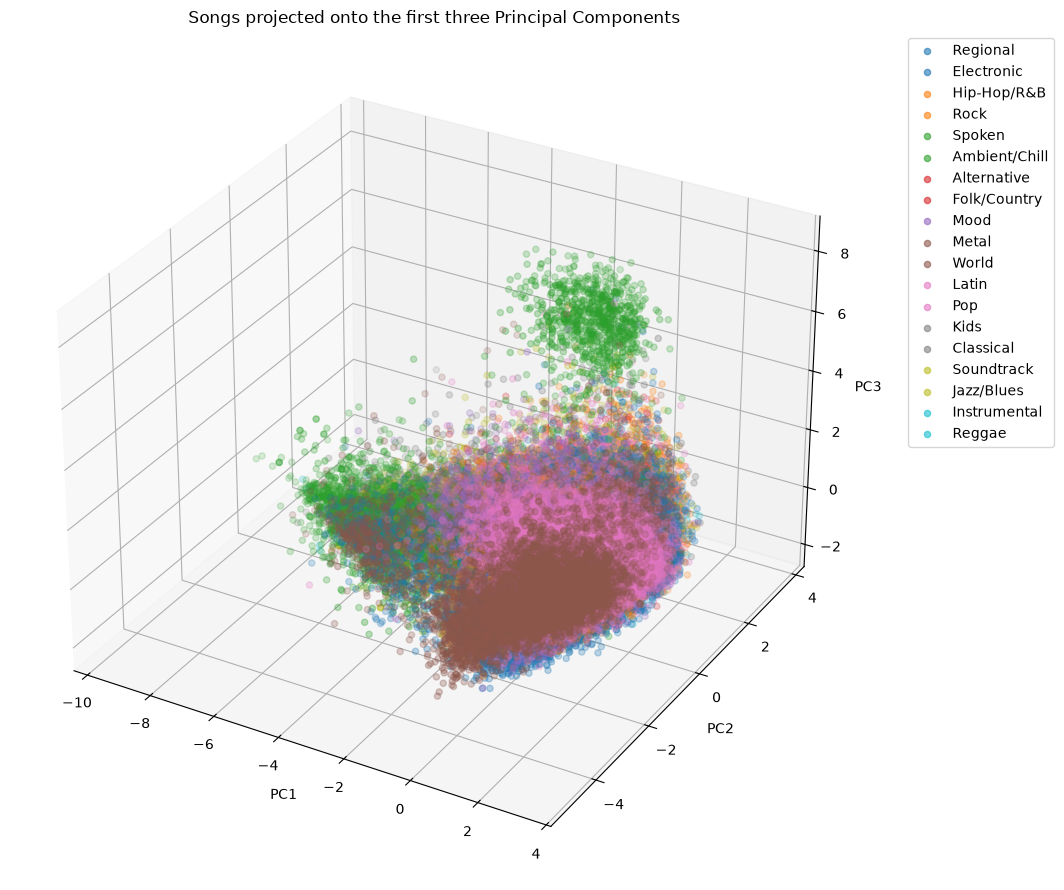

In [11]:
import matplotlib.pyplot as plt
import pandas as pd

# Creazione del DataFrame con le prime 3 componenti principali
pca_df = pd.DataFrame(X_pca[:, :3], columns=["PC1", "PC2", "PC3"])

pca_df["genre"] = spotify["macro_genre"].values

# Inizializzazione della figura e dell'asse 3D
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection="3d")

# Estrazione dei generi unici per mappare i colori
genres = pca_df["genre"].unique()

# CORREZIONE: Uso della nuova sintassi consigliata da Matplotlib
colors = plt.get_cmap("tab10")

# Loop per plottare ogni genere con il proprio colore
for i, genre in enumerate(genres):
    subset = pca_df[pca_df["genre"] == genre]
    # Calcolo del colore frazionario basato sul numero totale di generi
    color_idx = i / max(1, (len(genres) - 1))
    ax.scatter(
        subset["PC1"],
        subset["PC2"],
        subset["PC3"],
        label=genre,
        s=20,
        alpha=0.6,
        color=colors(color_idx),
    )

# Configurazione delle etichette degli assi e del titolo
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
plt.title("Songs projected onto the first three Principal Components")

# Mostra la legenda fuori dal grafico
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

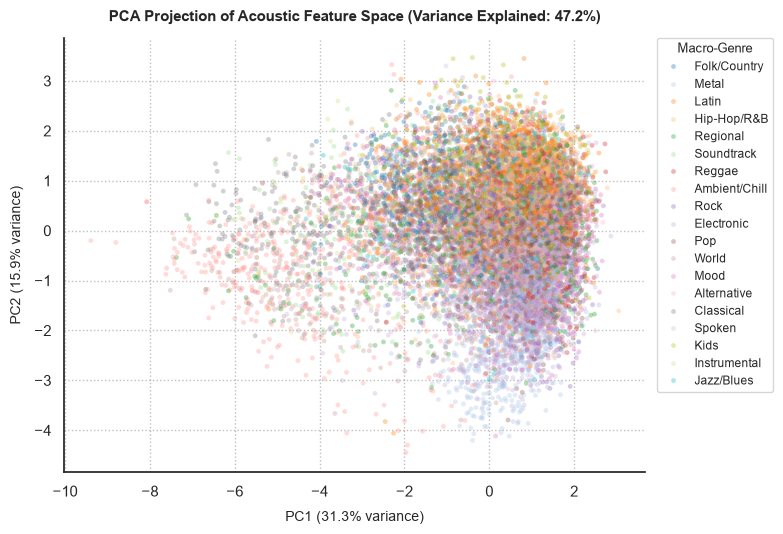

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Set publication style
sns.set_theme(style='white', palette='muted')

# 1. Compute PCA on standardized continuous features (if not already done)
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_coords = pca.fit_transform(spotify[continuous_features])

# Create a clean plotting dataframe
df_pca = pd.DataFrame(pca_coords, columns=['PC1', 'PC2'])
df_pca['macro_genre'] = spotify['macro_genre'].values

# Variance explained for axis labels
var_exp = pca.explained_variance_ratio_ * 100

# 2. Plot single compact 2D figure
fig, ax = plt.subplots(figsize=(8, 5.5))

# Palette with distinct colors for macro-genres
unique_genres = df_pca['macro_genre'].nunique()
palette = sns.color_palette('tab20', n_colors=unique_genres)

# Subsample if dataset > 15,000 points for fast rendering and clean export
df_sample = (
    df_pca.sample(n=15000, random_state=42)
    if len(df_pca) > 15000
    else df_pca
)

# Scatter plot with high transparency to highlight density centers
sns.scatterplot(
    data=df_sample,
    x='PC1',
    y='PC2',
    hue='macro_genre',
    palette=palette,
    alpha=0.35,
    s=12,
    edgecolor='none',
    ax=ax,
)

# Formatting
ax.set_title(
    f'PCA Projection of Acoustic Feature Space (Variance Explained: {sum(var_exp[:2]):.1f}%)',
    fontsize=11,
    fontweight='bold',
    pad=12,
)
ax.set_xlabel(f'PC1 ({var_exp[0]:.1f}% variance)', fontsize=10, labelpad=8)
ax.set_ylabel(f'PC2 ({var_exp[1]:.1f}% variance)', fontsize=10, labelpad=8)

# Grid and Clean borders
ax.grid(axis='both', linestyle=':', alpha=0.5, color='gray')
ax.set_axisbelow(True)
sns.despine(ax=ax)

# Place Legend cleanly on the outside right
ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    borderaxespad=0,
    frameon=True,
    facecolor='white',
    edgecolor='#cccccc',
    fontsize=8.5,
    title='Macro-Genre',
    title_fontsize=9.5,
)

plt.tight_layout()
plt.savefig('pca_2d_macro_genres.png', dpi=300, bbox_inches='tight')
plt.show()

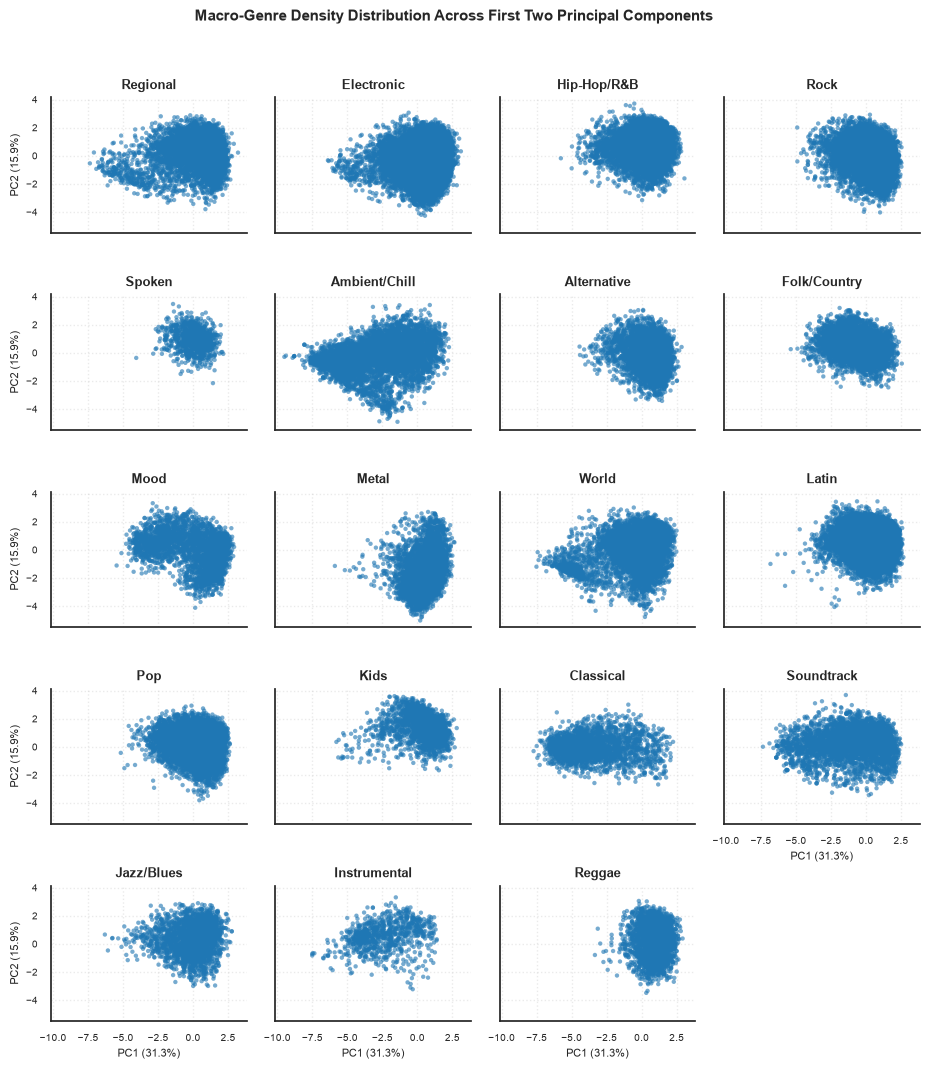

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Faceted grid for macro-genres
g = sns.FacetGrid(
    df_pca,
    col='macro_genre',
    col_wrap=4,
    height=2.2,
    aspect=1.1,
    sharex=True,
    sharey=True,
)

# 1. Background plot: All tracks in faint gray
g.map(
    sns.scatterplot,
    'PC1',
    'PC2',
    color='lightgray',
    alpha=0.15,
    s=5,
    edgecolor='none',
)

# 2. Foreground plot: Genre-specific tracks in color
g.map(
    sns.scatterplot,
    'PC1',
    'PC2',
    color='#1f77b4',
    alpha=0.6,
    s=10,
    edgecolor='none',
)

# Titles & formatting
g.set_titles(col_template='{col_name}', size=9, weight='bold')
g.set_axis_labels(
    f'PC1 ({var_exp[0]:.1f}%)', f'PC2 ({var_exp[1]:.1f}%)', fontsize=8
)

for ax in g.axes.flatten():
    ax.tick_params(labelsize=7)
    ax.grid(True, linestyle=':', alpha=0.4)

plt.subplots_adjust(top=0.9)
g.fig.suptitle(
    'Macro-Genre Density Distribution Across First Two Principal Components',
    fontsize=11,
    fontweight='bold',
)

plt.savefig('pca_macro_genres_faceted.png', dpi=300, bbox_inches='tight')
plt.show()

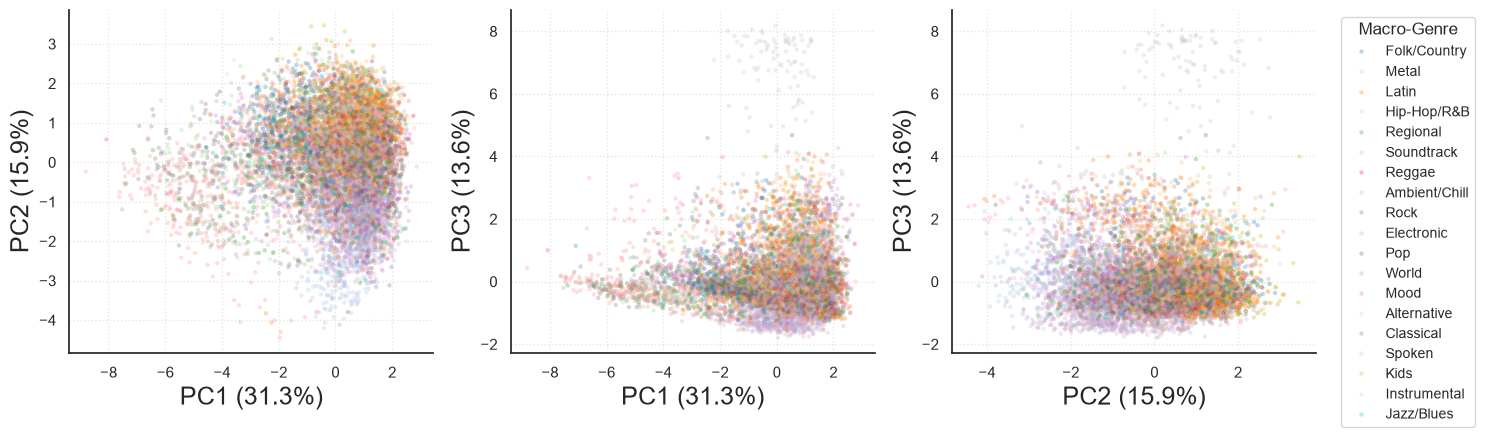

In [14]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA

# 1. Compute top 3 Principal Components
pca = PCA(n_components=3)
pca_coords = pca.fit_transform(spotify[continuous_features])

df_pca3 = pd.DataFrame(pca_coords, columns=['PC1', 'PC2', 'PC3'])
df_pca3['macro_genre'] = spotify['macro_genre'].values

var_exp = pca.explained_variance_ratio_ * 100

# 2. Plot 2D Pairwise Projections (PC1 vs PC2, PC1 vs PC3, PC2 vs PC3)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Pair combinations
pairs = [('PC1', 'PC2'), ('PC1', 'PC3'), ('PC2', 'PC3')]

# Sample points for performance/clarity if needed
df_sample = (
    df_pca3.sample(n=10000, random_state=42)
    if len(df_pca3) > 10000
    else df_pca3
)

palette = sns.color_palette('tab20', n_colors=df_pca3['macro_genre'].nunique())

for ax, (x_col, y_col) in zip(axes, pairs):
    sns.scatterplot(
        data=df_sample,
        x=x_col,
        y=y_col,
        hue='macro_genre',
        palette=palette,
        alpha=0.3,
        s=10,
        edgecolor='none',
        ax=ax,
        legend=(ax == axes[2]),  # Show legend only on last plot
    )

    # Format labels with variance explained
    x_idx = int(x_col[-1]) - 1
    y_idx = int(y_col[-1]) - 1
    ax.set_xlabel(f'{x_col} ({var_exp[x_idx]:.1f}%)', fontsize=18)
    ax.set_ylabel(f'{y_col} ({var_exp[y_idx]:.1f}%)', fontsize=18)
    ax.grid(True, linestyle=':', alpha=0.5)
    sns.despine(ax=ax)

# Place legend outside right
axes[2].legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    fontsize=10,
    title='Macro-Genre',
    frameon=True,
)

plt.tight_layout()
plt.savefig('pca_3components_2d_projections.png', dpi=300, bbox_inches='tight')
plt.show()

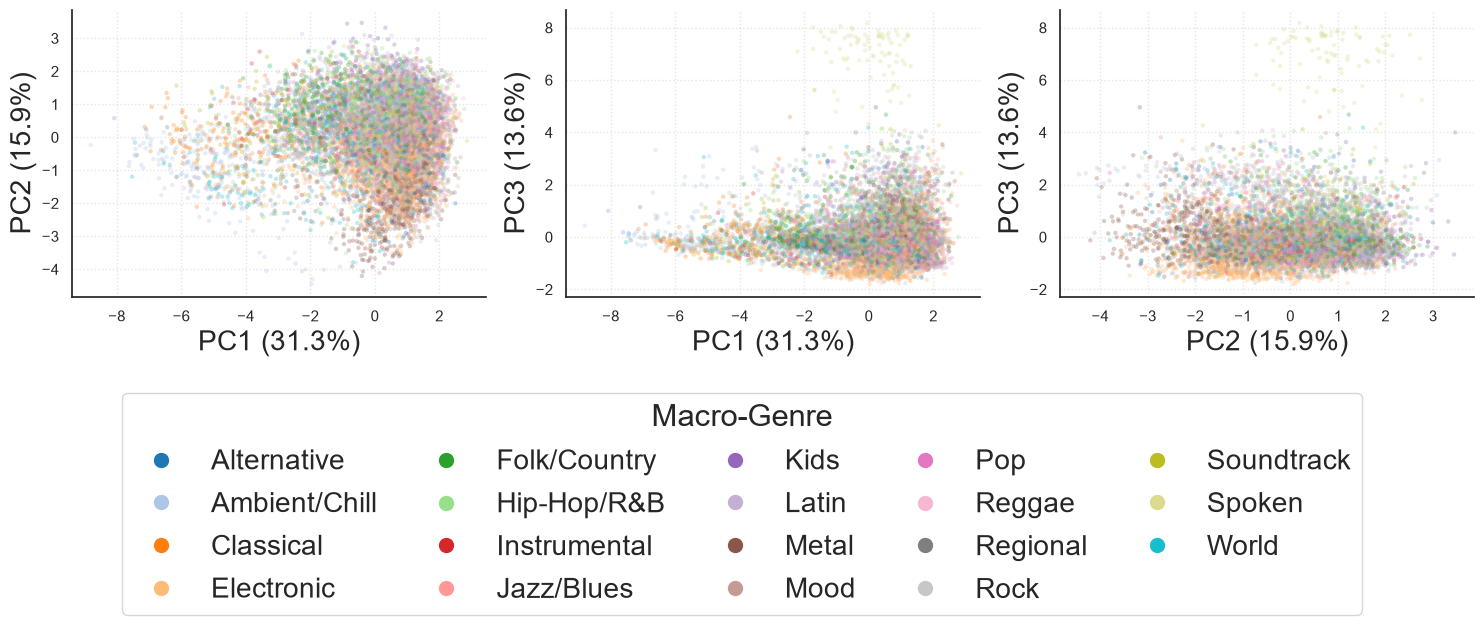

In [15]:
import matplotlib.lines as mlines
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA

# 1. Compute top 3 Principal Components
pca = PCA(n_components=3)
pca_coords = pca.fit_transform(spotify[continuous_features])

df_pca3 = pd.DataFrame(pca_coords, columns=['PC1', 'PC2', 'PC3'])
df_pca3['macro_genre'] = spotify['macro_genre'].values

var_exp = pca.explained_variance_ratio_ * 100

# 2. Plot 2D Pairwise Projections
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

pairs = [('PC1', 'PC2'), ('PC1', 'PC3'), ('PC2', 'PC3')]

df_sample = (
    df_pca3.sample(n=10000, random_state=42)
    if len(df_pca3) > 10000
    else df_pca3
)

genres = sorted(df_pca3['macro_genre'].unique())
palette = sns.color_palette('tab20', n_colors=len(genres))

# Loop through subplots
for ax, (x_col, y_col) in zip(axes, pairs):
    sns.scatterplot(
        data=df_sample,
        x=x_col,
        y=y_col,
        hue='macro_genre',
        hue_order=genres,
        palette=palette,
        alpha=0.3,
        s=10,
        edgecolor='none',
        ax=ax,
        legend=False,  # Keep disabled so it doesn't mess up subplot spacing
    )

    x_idx = int(x_col[-1]) - 1
    y_idx = int(y_col[-1]) - 1
    ax.set_xlabel(f'{x_col} ({var_exp[x_idx]:.1f}%)', fontsize=20)
    ax.set_ylabel(f'{y_col} ({var_exp[y_idx]:.1f}%)', fontsize=20)
    ax.tick_params(axis='both', labelsize=11)
    ax.grid(True, linestyle=':', alpha=0.5)
    sns.despine(ax=ax)

# Create explicit legend handles using the palette colors
# Create custom handles with LARGER dots (markersize=10 or 12)
legend_handles = [
    mlines.Line2D(
        [],
        [],
        color=color,
        marker='o',
        linestyle='None',
        markersize=10,  # <-- Increased dot size (was 6)
        label=genre,
    )
    for genre, color in zip(genres, palette)
]

# Place figure-level legend with LARGER fonts
fig.legend(
    handles=legend_handles,
    loc='upper center',
    bbox_to_anchor=(0.5, 0.14),
    ncol=5,
    title='Macro-Genre',
    title_fontsize=22,  # <-- Legend title size (was 12)
    fontsize=20,        # <-- Legend item text size (was 10)
    frameon=True,
    labelspacing=0.6,   # Slightly increases vertical space between rows
    columnspacing=1.5,  # Slightly increases horizontal space between columns
)

# Tight layout with space reserved for bottom legend
plt.tight_layout(rect=[0, 0.15, 1, 1])

plt.savefig('pca_3components_2d_projections.png', dpi=300, bbox_inches='tight')
plt.show()

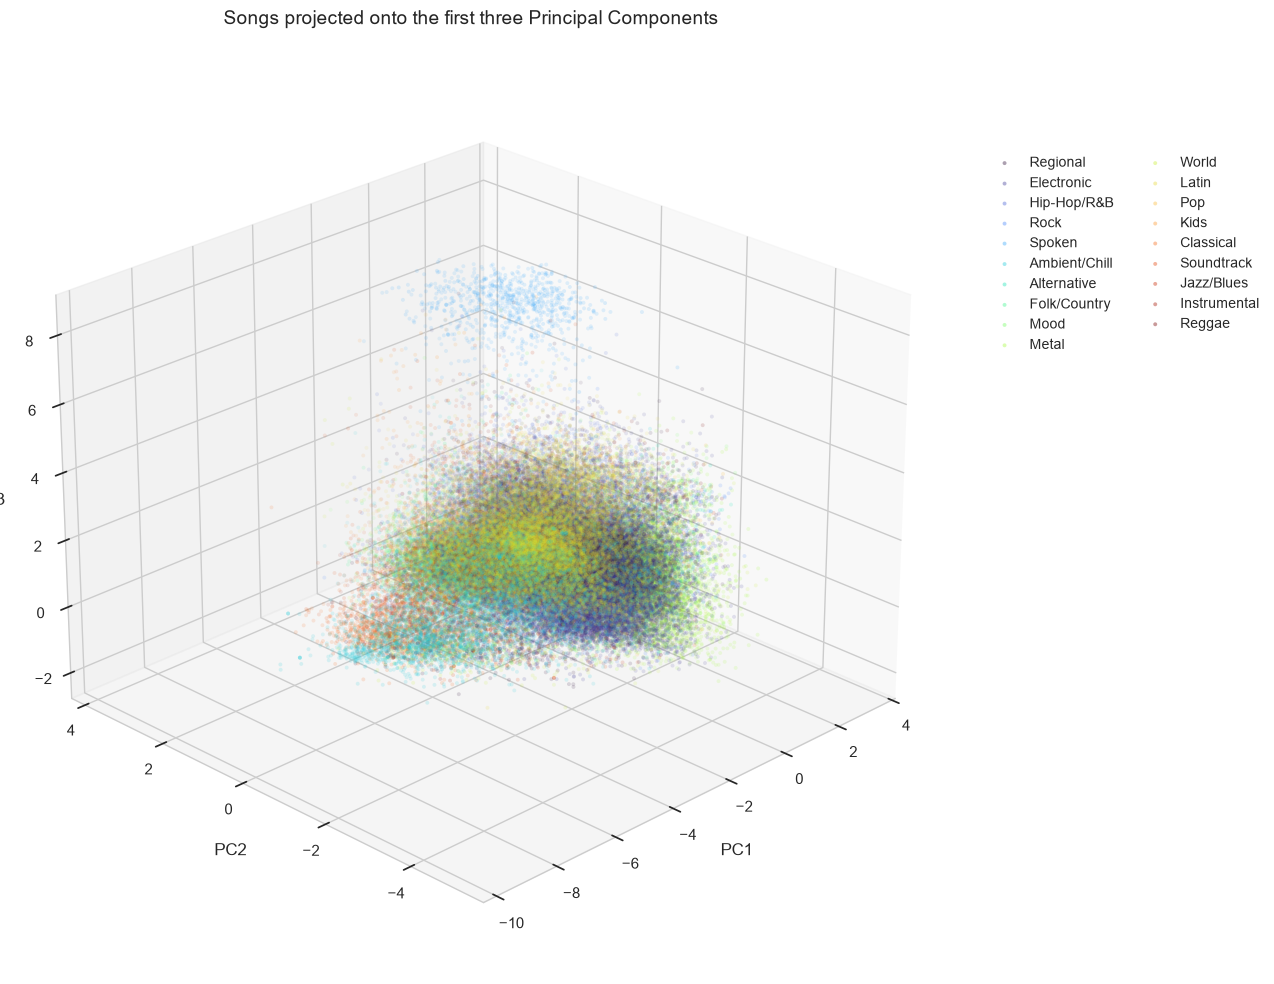

In [16]:
import matplotlib.pyplot as plt
import pandas as pd

# Creazione del DataFrame
pca_df = pd.DataFrame(X_pca[:, :3], columns=["PC1", "PC2", "PC3"])
pca_df["genre"] = spotify["macro_genre"].values

# Configurazione dello stile per una migliore percezione 3D
plt.style.use("seaborn-v0_8-whitegrid")  # Sfondo pulito con griglia chiara
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection="3d")

genres = pca_df["genre"].unique()

# SOLUZIONE COLORI: Uso di 'viridis' o 'turbo' per generare 19 colori unici e distinti
colors = plt.get_cmap("turbo", len(genres))

for i, genre in enumerate(genres):
    subset = pca_df[pca_df["genre"] == genre]

    ax.scatter(
        subset["PC1"],
        subset["PC2"],
        subset["PC3"],
        label=genre,
        s=8,  # SOLUZIONE DIMENSIONE: Punti molto più piccoli per ridurre il sovrappopolamento
        alpha=0.4,  # SOLUZIONE TRASPARENZA: Maggiore trasparenza per vedere attraverso i cluster
        color=colors(i),
        edgecolors="none",  # Rimuove il bordo dei punti per renderli più definiti
    )

# Etichette e Titolo
ax.set_xlabel("PC1", fontsize=12, labelpad=10)
ax.set_ylabel("PC2", fontsize=12, labelpad=10)
ax.set_zlabel("PC3", fontsize=12, labelpad=10)
plt.title(
    "Songs projected onto the first three Principal Components",
    fontsize=14,
    pad=20,
)

# SOLUZIONE PROSPETTIVA: Ruota il grafico per trovare un angolo visivo migliore
ax.view_init(elev=25, azim=-135)

# Legenda ordinata su due colonne per risparmiare spazio verticale
plt.legend(bbox_to_anchor=(1.05, 0.9), loc="upper left", ncol=2, fontsize=10)
plt.tight_layout()
plt.show()


C:\Users\pietr\AppData\Local\Temp\ipykernel_24296\2498300550.py:52: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


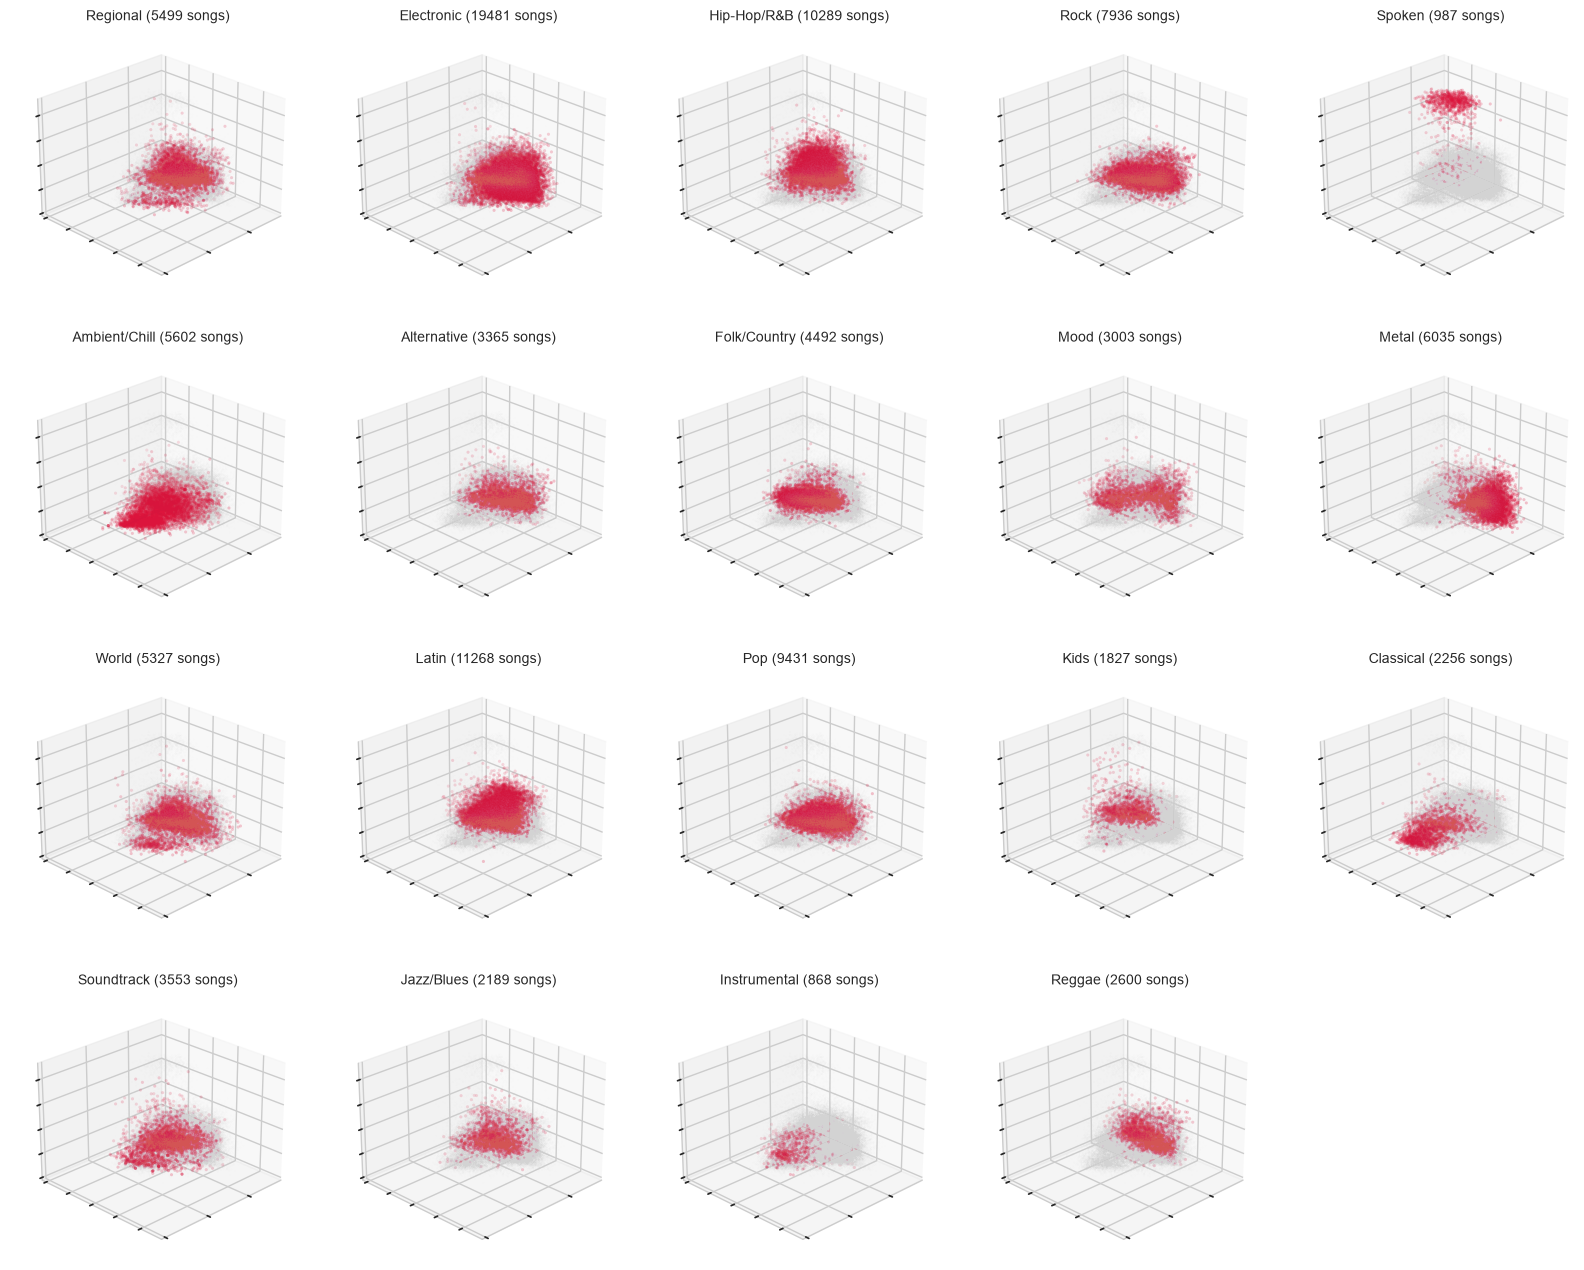

In [17]:
import math
import matplotlib.pyplot as plt
import pandas as pd

# Configurazione del DataFrame
pca_df = pd.DataFrame(X_pca[:, :3], columns=["PC1", "PC2", "PC3"])
pca_df["genre"] = spotify["macro_genre"].values

genres = pca_df["genre"].unique()
n_genres = len(genres)

# Calcolo automatico di righe e colonne per la griglia
cols = 5
rows = math.ceil(n_genres / cols)

fig = plt.figure(figsize=(20, rows * 4))

for i, genre in enumerate(genres):
    ax = fig.add_subplot(rows, cols, i + 1, projection="3d")

    # 1. Plot di SFONDO: Tutti gli altri generi in grigio chiarissimo e trasparente
    bg_data = pca_df[pca_df["genre"] != genre]
    ax.scatter(
        bg_data["PC1"],
        bg_data["PC2"],
        bg_data["PC3"],
        color="lightgray",
        s=2,
        alpha=0.1,
        edgecolors="none",
    )

    # 2. Plot in PRIMO PIANO: Il genere specifico in evidenza
    fg_data = pca_df[pca_df["genre"] == genre]
    ax.scatter(
        fg_data["PC1"],
        fg_data["PC2"],
        fg_data["PC3"],
        color="crimson",
        s=5,
        alpha=0.5,
        edgecolors="none",
    )

    # Pulizia assi per concentrarsi sulla forma del cluster
    ax.set_title(f"{genre} ({len(fg_data)} songs)", fontsize=10)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_zticklabels([])
    ax.view_init(elev=25, azim=-135)

plt.tight_layout()
plt.savefig('full_pca_3d_projections.png', dpi=300, bbox_inches='tight')
plt.show()

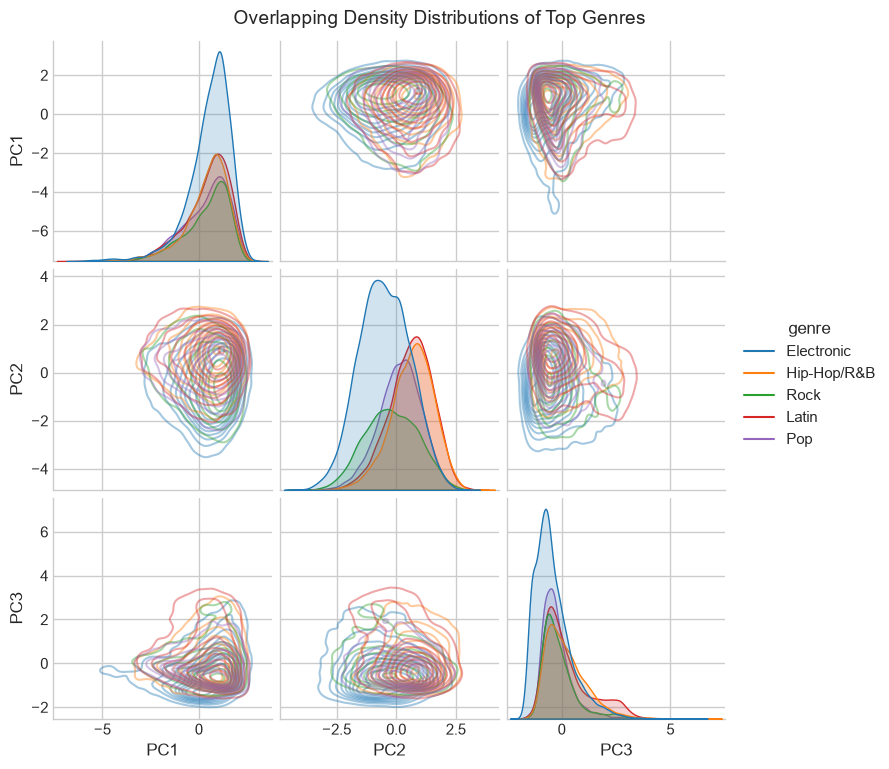

In [18]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

pca_df = pd.DataFrame(X_pca[:, :3], columns=["PC1", "PC2", "PC3"])
pca_df["genre"] = spotify["macro_genre"].values

# Seleziona i 5 o 6 generi più popolari per non affollare il grafico, o usa l'intero DF
top_genres = pca_df["genre"].value_counts().nlargest(5).index
subset_df = pca_df[pca_df["genre"].isin(top_genres)]

# Grafico delle densità incrociate (PairPlot KDE) per PC1, PC2 e PC3
g = sns.pairplot(
    data=subset_df,
    vars=["PC1", "PC2", "PC3"],
    hue="genre",
    kind="kde",  # Mostra le curve di livello della densità anziché i punti
    plot_kws={"alpha": 0.4, "linewidths": 1.5},
    diag_kws={"fill": True, "alpha": 0.2},
    palette="tab10",
)

g.fig.suptitle(
    "Overlapping Density Distributions of Top Genres", y=1.02, fontsize=14
)

plt.savefig('pca_density.png', dpi=300, bbox_inches='tight')
plt.show()

### We can start to cluster without PCA

Given the previous analysis we decided to cluster with the orginal features, excluding key and mdoe, and explore clustering with 2 and 8 clusters

In [19]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init="auto"
)

clusters_2 = kmeans.fit_predict(X_for_clustering)

kmeans = KMeans(
    n_clusters=8,
    random_state=42,
    n_init="auto"
)

clusters_8 = kmeans.fit_predict(X_for_clustering)

kmeans = KMeans(
    n_clusters=19,
    random_state=42,
    n_init="auto"
)

clusters_19 = kmeans.fit_predict(X_for_clustering)


spotify["cluster_2"] = clusters_2
spotify["cluster_8"] = clusters_8
spotify["cluster_19"] = clusters_19

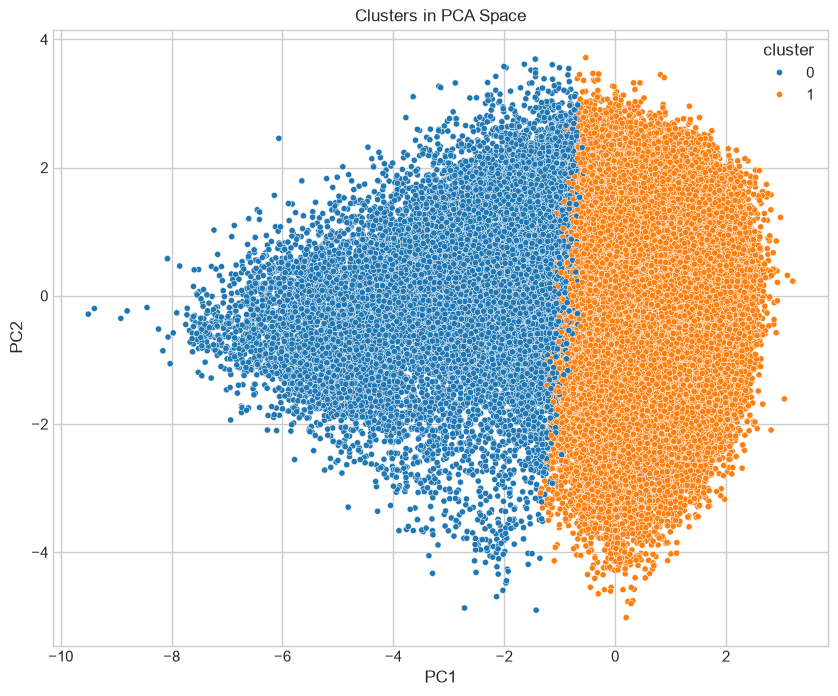

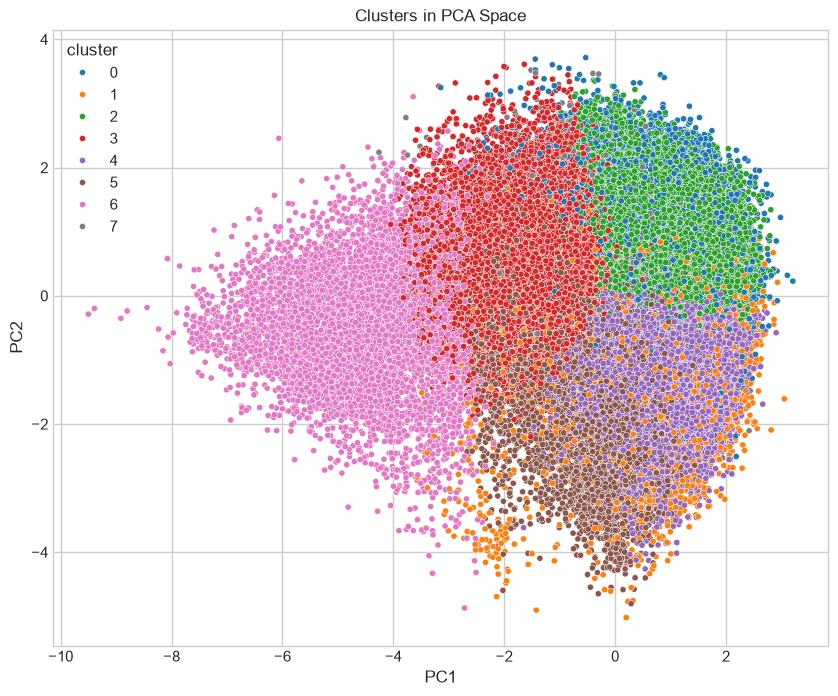

In [20]:
pca_df["cluster"] = clusters_2

plt.figure(figsize=(10,8))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="tab10",
    s=20
)

plt.title("Clusters in PCA Space")

plt.show()

pca_df["cluster"] = clusters_8

plt.figure(figsize=(10,8))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="tab10",
    s=20
)

plt.title("Clusters in PCA Space")

plt.show()

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
cluster_2,,,,,,,,,
0,-0.61,-1.38,-1.22,-0.27,1.34,0.51,-0.17,-0.62,-0.40
1,0.18,0.40,0.35,0.08,-0.39,-0.15,0.05,0.18,0.12


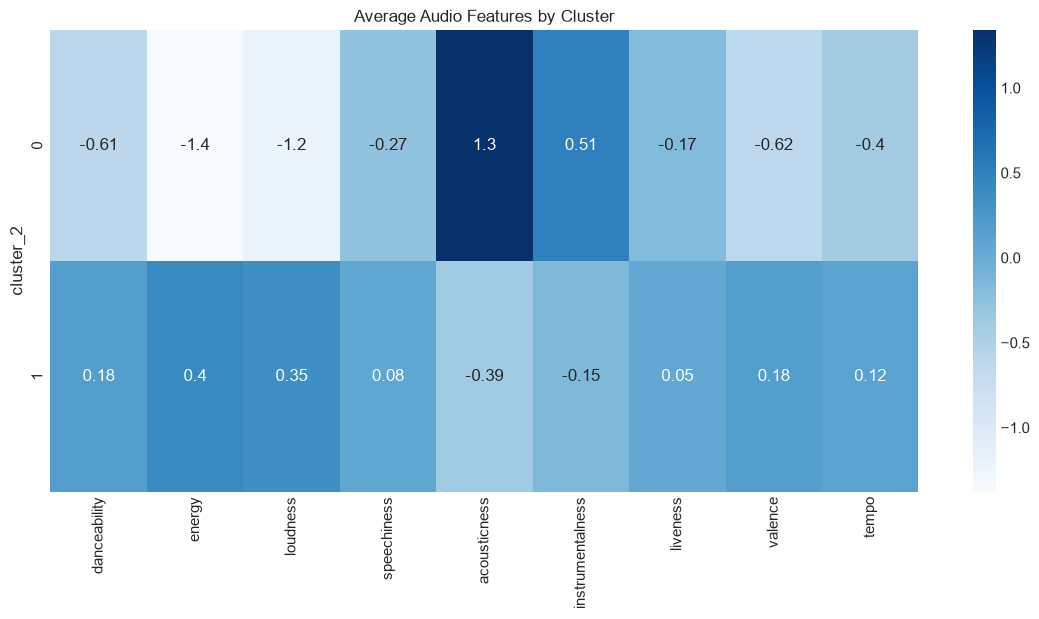

In [24]:
cluster_profile = (
    spotify.groupby("cluster_2")[X_for_clustering.columns]
      .mean()
      .round(2)
)

display(cluster_profile)

plt.figure(figsize=(14,6))

sns.heatmap(
    cluster_profile,
    cmap="Blues",
    annot=True
)

plt.title("Average Audio Features by Cluster")

plt.show()

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
cluster_8,,,,,,,,,
0,0.79,0.05,0.22,1.89,-0.20,-0.46,-0.18,0.31,-0.01
1,-0.31,0.45,0.26,-0.05,-0.10,-0.26,2.76,0.08,0.05
2,0.70,0.32,0.35,-0.25,-0.31,-0.45,-0.27,0.89,-0.15
3,-0.25,-1.09,-0.48,-0.38,1.14,-0.40,-0.29,-0.33,-0.29
4,-0.55,0.67,0.57,-0.15,-0.70,-0.41,-0.11,-0.44,0.54
5,0.09,0.40,-0.01,-0.21,-0.58,1.99,-0.24,-0.48,0.16
6,-1.32,-1.94,-2.62,-0.36,1.74,1.95,-0.26,-1.13,-0.65
7,-0.12,0.19,-0.61,6.86,1.47,-0.50,2.62,-0.15,-0.75


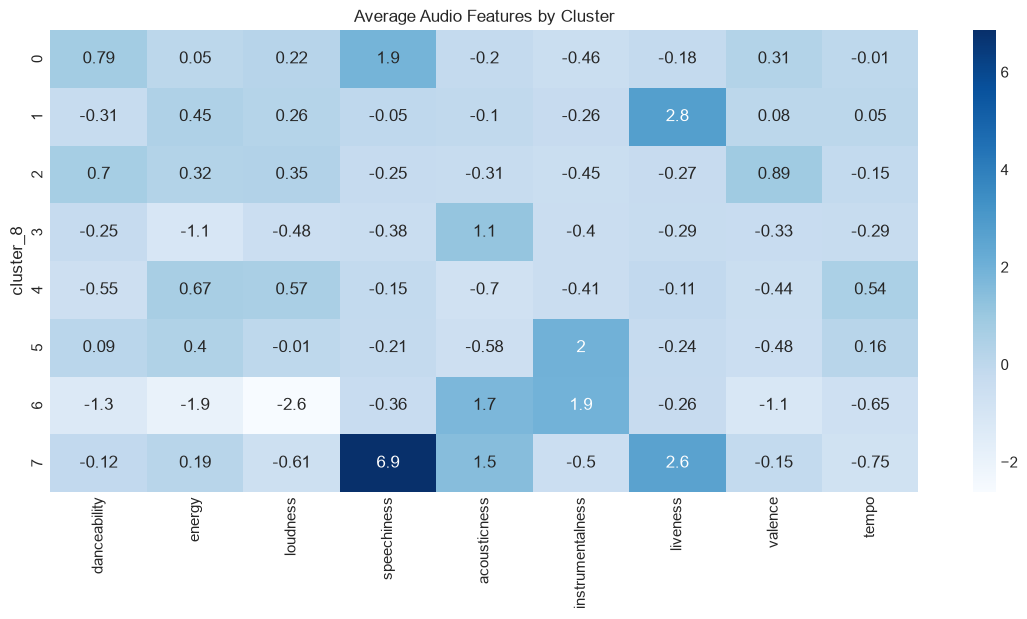

In [25]:
cluster_profile = (
    spotify.groupby("cluster_8")[X_for_clustering.columns]
      .mean()
      .round(2)
)

display(cluster_profile)

plt.figure(figsize=(14,6))

sns.heatmap(
    cluster_profile,
    cmap="Blues",
    annot=True
)

plt.title("Average Audio Features by Cluster")
plt.savefig('k8_feature_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

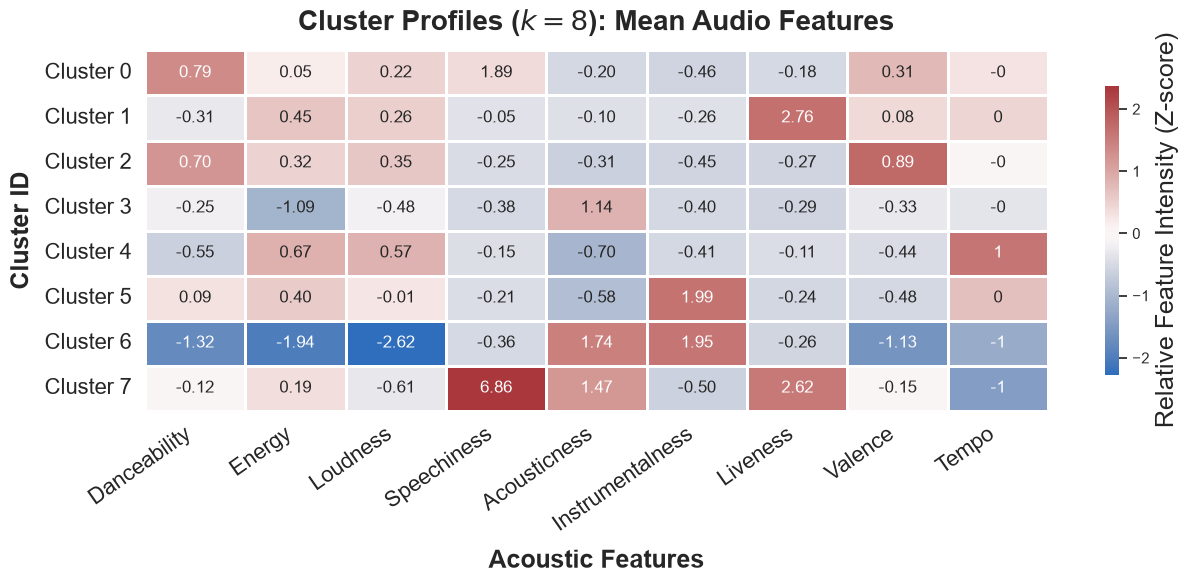

In [35]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

TITLE_SIZE = 20
LABEL_SIZE = 18
TICKS_SIZE = 16
ANNOT_SIZE = 12

# 1. Compute raw mean profile
raw_profile = spotify.groupby("cluster_8")[X_for_clustering.columns].mean()

# 2. Compute Z-score profile (for standardized color mapping)
z_profile = (raw_profile - raw_profile.mean()) / raw_profile.std()

# 3. Format raw numbers for clear cell annotations
# Round values, but format tempo as integer for cleanliness
annot_matrix = raw_profile.copy()
for col in annot_matrix.columns:
    if col == "tempo":
        annot_matrix[col] = annot_matrix[col].map("{:.0f}".format)
    else:
        annot_matrix[col] = annot_matrix[col].map("{:.2f}".format)

# Set publication style
sns.set_theme(style="white")

fig, ax = plt.subplots(figsize=(13, 6))

# Plot Diverging Heatmap using Z-scores for colors and raw values for annotations
sns.heatmap(
    z_profile,
    annot=annot_matrix.values,  # Display true unscaled means
    fmt="",  # Pre-formatted string matrix
    cmap="vlag",  # Diverging palette (blue = low, red = high relative to feature mean)
    center=0,
    linewidths=0.75,
    linecolor="white",
    cbar_kws={
        "shrink": 0.8,
        "label": "Relative Feature Intensity (Z-score)",
    },
    annot_kws={"size": ANNOT_SIZE, "weight": "medium"},
    ax=ax,
)

# 2. Access the colorbar axes to change font sizes
cbar_axes = ax.collections[0].colorbar.ax
# Change the main colorbar title/label font size
cbar_axes.yaxis.label.set_size(LABEL_SIZE)

# Capitalize & clean feature/cluster labels
ax.set_title(
    "Cluster Profiles ($k=8$): Mean Audio Features",
    fontsize=TITLE_SIZE,
    fontweight="bold",
    pad=14,
)
ax.set_ylabel("Cluster ID", fontsize=LABEL_SIZE, fontweight="bold", labelpad=8)
ax.set_xlabel("Acoustic Features", fontsize=LABEL_SIZE, fontweight="bold", labelpad=10)

# Format ticks
ax.set_xticklabels(
    [col.capitalize() for col in X_for_clustering.columns],
    rotation=35,
    ha="right",
    fontsize=TICKS_SIZE,
)
ax.set_yticklabels(
    [f"Cluster {c}" for c in raw_profile.index], rotation=0, fontsize=TICKS_SIZE
)

plt.tight_layout()
plt.savefig("k8_feature_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

cluster_2,0,1
macro_genre,,
Alternative,0.133432,0.866568
Ambient/Chill,0.720993,0.279007
Classical,0.856826,0.143174
Electronic,0.077717,0.922283
Folk/Country,0.502671,0.497329
Hip-Hop/R&B,0.120906,0.879094
Instrumental,0.773041,0.226959
Jazz/Blues,0.259022,0.740978
Kids,0.207991,0.792009


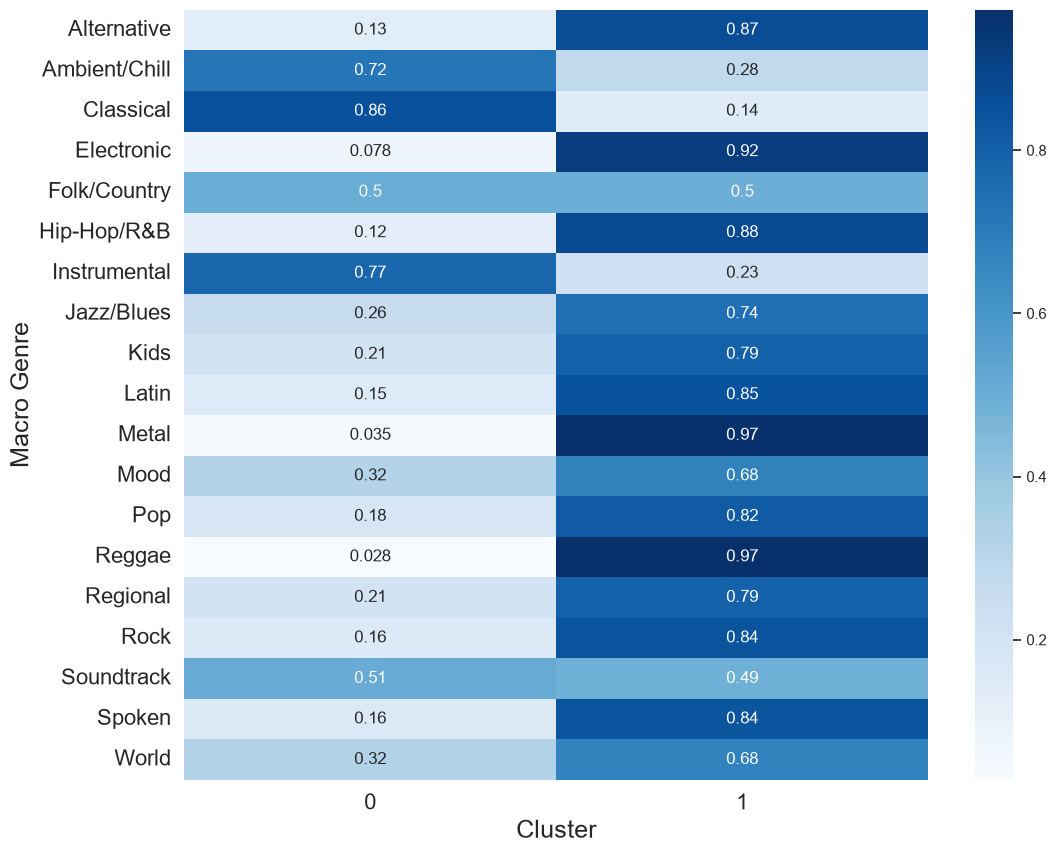

In [38]:
TITLE_SIZE = 20
LABEL_SIZE = 18
TICKS_SIZE = 16
ANNOT_SIZE = 12


genre_cluster = pd.crosstab(
    spotify["macro_genre"],
    spotify["cluster_2"],
    normalize="index"
)

display(genre_cluster)

plt.figure(figsize=(12,10))

sns.heatmap(
    genre_cluster,
    cmap="Blues",
    annot=True,
    annot_kws={"size": ANNOT_SIZE}
)

# plt.title(
#     "Genre Distribution Across Clusters",
#     fontsize=TITLE_SIZE
# )

plt.xlabel(
    "Cluster",
    fontsize=LABEL_SIZE
)

plt.ylabel(
    "Macro Genre",
    fontsize=LABEL_SIZE
)

plt.xticks(fontsize=TICKS_SIZE)
plt.yticks(fontsize=TICKS_SIZE)

plt.savefig(
    'k2_heatmap.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

cluster_8,0,1,2,3,4,5,6,7
macro_genre,,,,,,,,
Alternative,0.075483,0.065973,0.252897,0.181278,0.378900,0.037444,0.007132,0.000892
Ambient/Chill,0.036416,0.042485,0.069618,0.176009,0.038201,0.197429,0.438415,0.001428
Classical,0.003989,0.032801,0.039450,0.313830,0.055851,0.004876,0.547429,0.001773
Electronic,0.046712,0.054207,0.235358,0.040296,0.275140,0.329963,0.017658,0.000667
Folk/Country,0.010463,0.040294,0.235085,0.538958,0.121104,0.028495,0.025378,0.000223
Hip-Hop/R&B,0.305861,0.037613,0.348722,0.143551,0.112450,0.034308,0.015065,0.002430
Instrumental,0.001152,0.014977,0.126728,0.317972,0.011521,0.115207,0.412442,0.000000
Jazz/Blues,0.122887,0.097762,0.266332,0.292828,0.181361,0.015532,0.020557,0.002741
Kids,0.183908,0.029557,0.501916,0.191571,0.042693,0.013136,0.022441,0.014778


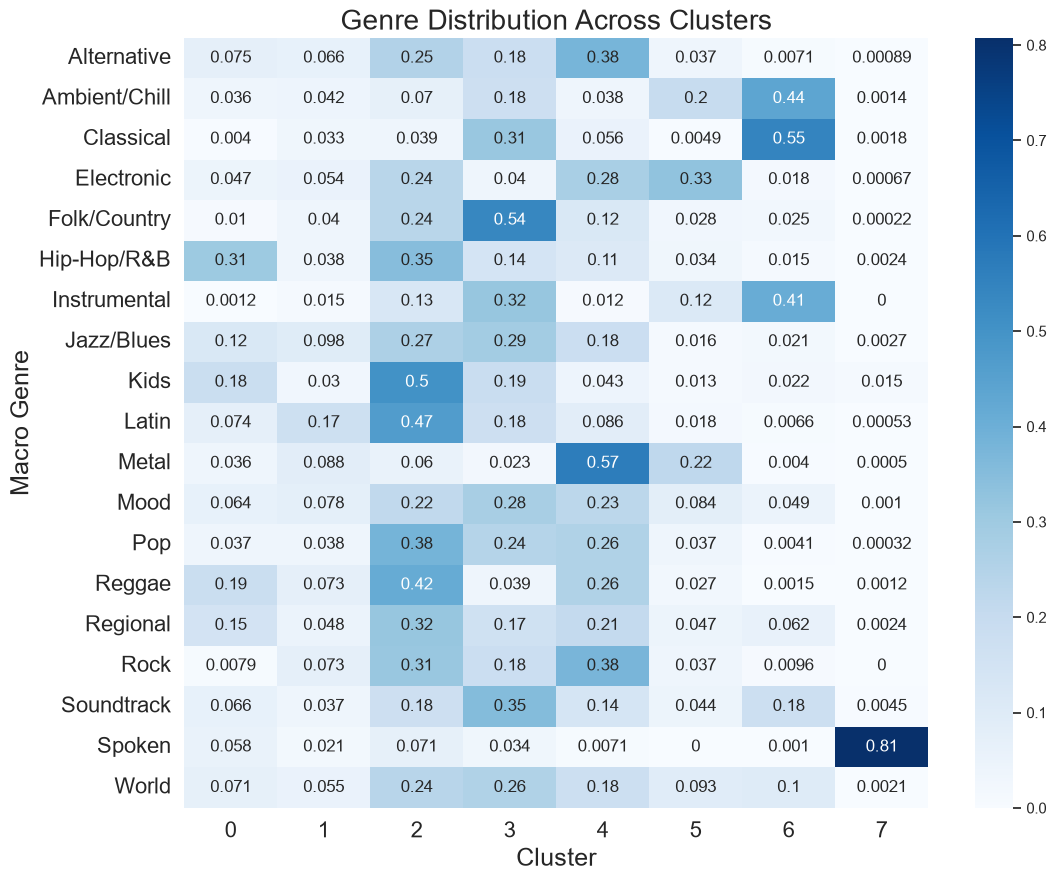

In [ ]:
TITLE_SIZE = 20
LABEL_SIZE = 18
TICKS_SIZE = 16
ANNOT_SIZE = 12


genre_cluster = pd.crosstab(
    spotify["macro_genre"],
    spotify["cluster_8"],
    normalize="index"
)

display(genre_cluster)

plt.figure(figsize=(12,10))

sns.heatmap(
    genre_cluster,
    cmap="Blues",
    annot=True,
    annot_kws={"size": ANNOT_SIZE}
)

# plt.title(
#     "Genre Distribution Across Clusters",
#     fontsize=TITLE_SIZE
# )

plt.xlabel(
    "Cluster",
    fontsize=LABEL_SIZE
)

plt.ylabel(
    "Macro Genre",
    fontsize=LABEL_SIZE
)

plt.xticks(fontsize=TICKS_SIZE)
plt.yticks(fontsize=TICKS_SIZE)

plt.savefig(
    'k8_heatmap.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

C:\Users\pietr\AppData\Local\Temp\ipykernel_24296\1845584139.py:102: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


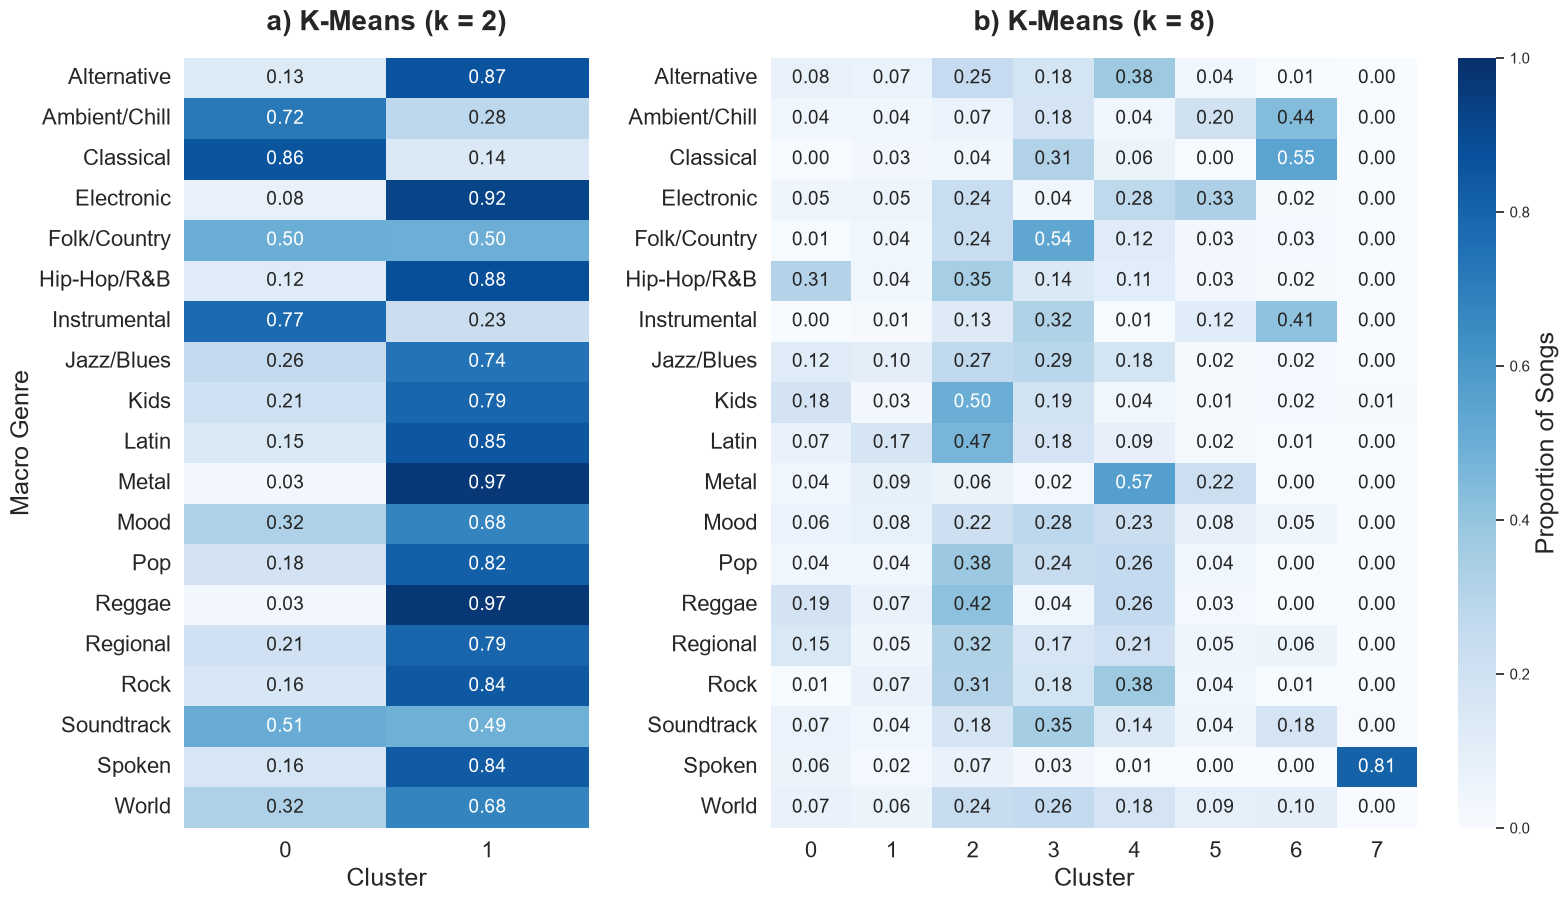

In [90]:
TITLE_SIZE = 20
LABEL_SIZE = 18
TICKS_SIZE = 16
ANNOT_SIZE = 14

# Compute both normalized cross-tabs
genre_cluster_2 = pd.crosstab(
    spotify["macro_genre"],
    spotify["cluster_2"],
    normalize="index"
)

genre_cluster_8 = pd.crosstab(
    spotify["macro_genre"],
    spotify["cluster_8"],
    normalize="index"
)

# Create figure
fig, axes = plt.subplots(
    1, 2,
    figsize=(18, 10),
    gridspec_kw={
        "width_ratios": [1, 2],
        "wspace": 0.30
    }
)

# k = 2
sns.heatmap(
    genre_cluster_2,
    cmap="Blues",
    annot=True,
    fmt=".2f",
    vmin=0,
    vmax=1,
    annot_kws={"size": ANNOT_SIZE},
    cbar=False,
    ax=axes[0]
)

axes[0].set_title(
    "a) K-Means (k = 2)",
    fontsize=TITLE_SIZE,
    fontweight="bold",
    pad=20
)

axes[0].set_xlabel(
    "Cluster",
    fontsize=LABEL_SIZE
)

axes[0].set_ylabel(
    "Macro Genre",
    fontsize=LABEL_SIZE
)

axes[0].tick_params(
    axis="both",
    labelsize=TICKS_SIZE
)


# k = 8
ax = sns.heatmap(
    genre_cluster_8,
    cmap="Blues",
    annot=True,
    fmt=".2f",
    vmin=0,
    vmax=1,
    annot_kws={"size": ANNOT_SIZE},
    cbar_kws={"label": "Proportion of Songs"},
    ax=axes[1]
)

axes[1].set_title(
    "b) K-Means (k = 8)",
    fontsize=TITLE_SIZE,
    fontweight="bold",
    pad=20
)

axes[1].set_xlabel(
    "Cluster",
    fontsize=LABEL_SIZE
)

axes[1].set_ylabel("")

axes[1].tick_params(
    axis="both",
    labelsize=TICKS_SIZE
)

cbar_axes = ax.collections[0].colorbar.ax

# Change the main colorbar title/label font size
cbar_axes.yaxis.label.set_size(LABEL_SIZE)

plt.tight_layout()

plt.savefig(
    "k2_k8_heatmaps.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [46]:
from sklearn.preprocessing import MinMaxScaler

cluster_mean = (
    spotify
    .groupby("cluster_8")[X_for_clustering.columns]
    .mean()
)

scaler_radar = MinMaxScaler()

cluster_mean_01 = pd.DataFrame(
    scaler_radar.fit_transform(cluster_mean),
    index=cluster_mean.index,
    columns=cluster_mean.columns
)

In [47]:
cluster_std = (
    spotify
    .groupby("cluster_8")[X_for_clustering.columns]
    .std()
)

In [48]:
cluster_dispersion = cluster_std.mean(axis=1).sort_values()

display(cluster_dispersion)

cluster_8
2    0.550872
4    0.578455
3    0.644490
0    0.708361
5    0.713975
7    0.782910
1    0.801450
6    0.845398
dtype: float64

In [49]:
cluster_profile = (
    spotify.groupby("cluster_8")[X_for_clustering.columns]
    .mean()
)

cluster_std = (
    spotify.groupby("cluster_8")[X_for_clustering.columns]
    .std()
)

cluster_std

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
cluster_8,,,,,,,,,
0,0.742848,0.676745,0.590322,0.800668,0.676124,0.321786,0.648249,0.794483,1.124027
1,0.880545,0.728040,0.666729,0.656115,0.859024,0.693826,0.804585,0.948075,0.976109
2,0.591350,0.583411,0.519683,0.346145,0.628732,0.266557,0.547396,0.688087,0.786490
3,0.816695,0.569147,0.654980,0.341296,0.721911,0.403167,0.533897,0.792761,0.966556
4,0.732503,0.585203,0.433111,0.479804,0.367144,0.309627,0.598071,0.723615,0.977015
5,1.034402,0.794759,0.680033,0.434298,0.612871,0.440544,0.640652,0.962709,0.825506
6,1.079721,0.644075,1.282939,0.381298,0.668887,0.865631,0.808625,0.702606,1.174804
7,0.511691,0.823950,1.030314,0.947287,0.532186,0.219172,1.172311,0.792671,1.016608


In [51]:
spotify[X_for_clustering.columns].describe()

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
count,1.060080e+05,1.060080e+05,1.060080e+05,1.060080e+05,1.060080e+05,1.060080e+05,1.060080e+05,1.060080e+05,1.060080e+05
mean,6.977539e-17,1.018815e-17,-1.979986e-16,-3.364769e-17,5.308560e-17,2.118062e-17,-5.208019e-17,2.319144e-17,1.882126e-16
std,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00
min,-3.314789e+00,-2.651709e+00,-8.386546e+00,-8.223497e-01,-9.131134e-01,-5.218557e-01,-1.122827e+00,-1.837339e+00,-4.144119e+00
25%,-6.318052e-01,-6.582811e-01,-3.445887e-01,-4.984374e-01,-8.651709e-01,-5.218557e-01,-6.108393e-01,-8.245081e-01,-7.531632e-01
50%,9.163213e-02,1.709523e-01,2.437334e-01,-3.697480e-01,-4.553400e-01,-5.216573e-01,-4.328023e-01,-3.287015e-02,5.838216e-03
75%,7.410168e-01,8.286203e-01,6.421694e-01,2.441824e-02,7.602339e-01,-2.848507e-01,3.204311e-01,8.014541e-01,6.163111e-01
max,2.296122e+00,1.433185e+00,2.581198e+00,7.625632e+00,2.167578e+00,2.654091e+00,4.144539e+00,2.023836e+00,4.132873e+00


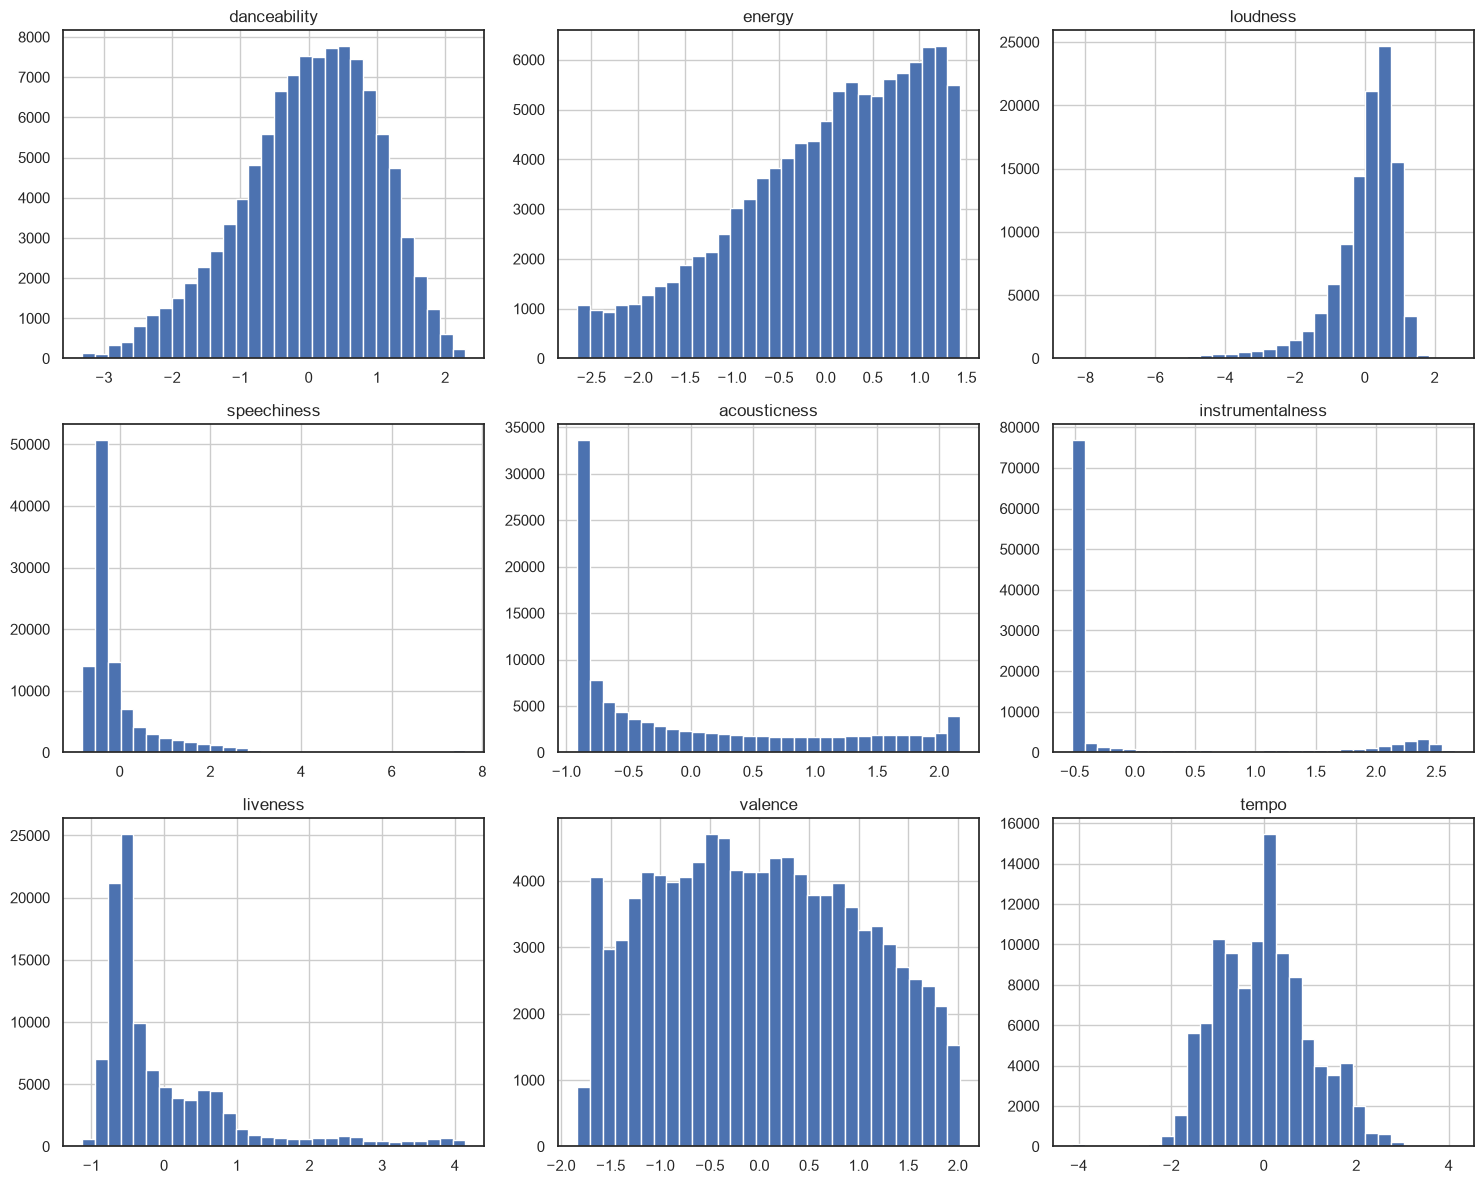

In [52]:
spotify[continuous_features].hist(
    bins=30,
    figsize=(15,12)
)

plt.tight_layout()
plt.show()

In [53]:
centroid_variation = (
    cluster_profile.var(axis=0)
    .sort_values(ascending=False)
)

display(centroid_variation)

speechiness         6.335871
liveness            1.825581
instrumentalness    1.223015
loudness            1.050010
acousticness        0.955442
energy              0.826602
danceability        0.458229
valence             0.361163
tempo               0.181688
dtype: float64

<Axes: ylabel='cluster_8'>

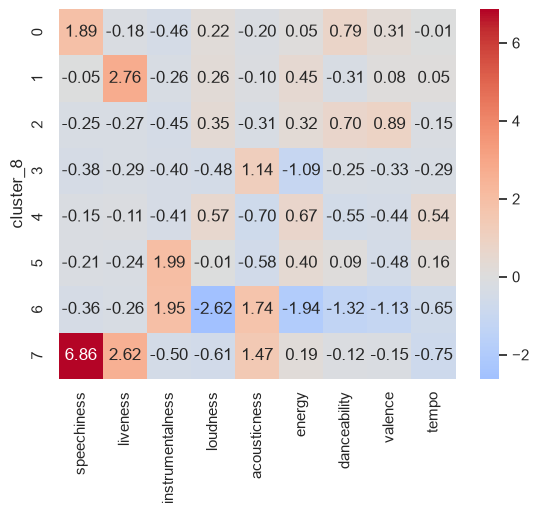

In [54]:
importance = cluster_profile.var(axis=0).sort_values(ascending=False).index

sns.heatmap(
    cluster_profile[importance],
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f"
)

In [56]:
vc = pca_df["cluster"].value_counts()
print(vc)

cluster
2    29339
4    22946
3    18619
5    11713
0     8814
1     6978
6     6657
7      942
Name: count, dtype: int64


In [57]:
# compute silhouette score and ARI, NMI for cluster evaluation
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score


# Definiamo le colonne dei cluster da ciclare
cluster_cols = ["cluster_2", "cluster_8", "cluster_19"]
ground_truth = spotify["macro_genre"]

for col in cluster_cols:
    ari = adjusted_rand_score(ground_truth, spotify[col])
    nmi = normalized_mutual_info_score(ground_truth, spotify[col])
    
    print(f"Configurazione {col}:")
    print(f"  -> ARI: {ari:.4f}")
    print(f"  -> NMI: {nmi:.4f}\n")

Configurazione cluster_2:
  -> ARI: 0.0336
  -> NMI: 0.0653

Configurazione cluster_8:
  -> ARI: 0.0599
  -> NMI: 0.1402

Configurazione cluster_19:
  -> ARI: 0.0520
  -> NMI: 0.1412



In [58]:
# Definiamo le colonne dei cluster da ciclare
cluster_cols = ["cluster_2", "cluster_8", "cluster_19"]
ground_truth = spotify["macro_genre"]

for col in cluster_cols:
    # Calcolo del Silhouette Score usando le feature numeriche originarie
    sil = silhouette_score(X_for_clustering, spotify[col], sample_size=30000, random_state=42)
    
    print(f"Configurazione {col}:")
    print(f"  -> Silhouette Score: {sil:.4f}")

Configurazione cluster_2:
  -> Silhouette Score: 0.2680
Configurazione cluster_8:
  -> Silhouette Score: 0.1888
Configurazione cluster_19:
  -> Silhouette Score: 0.1456


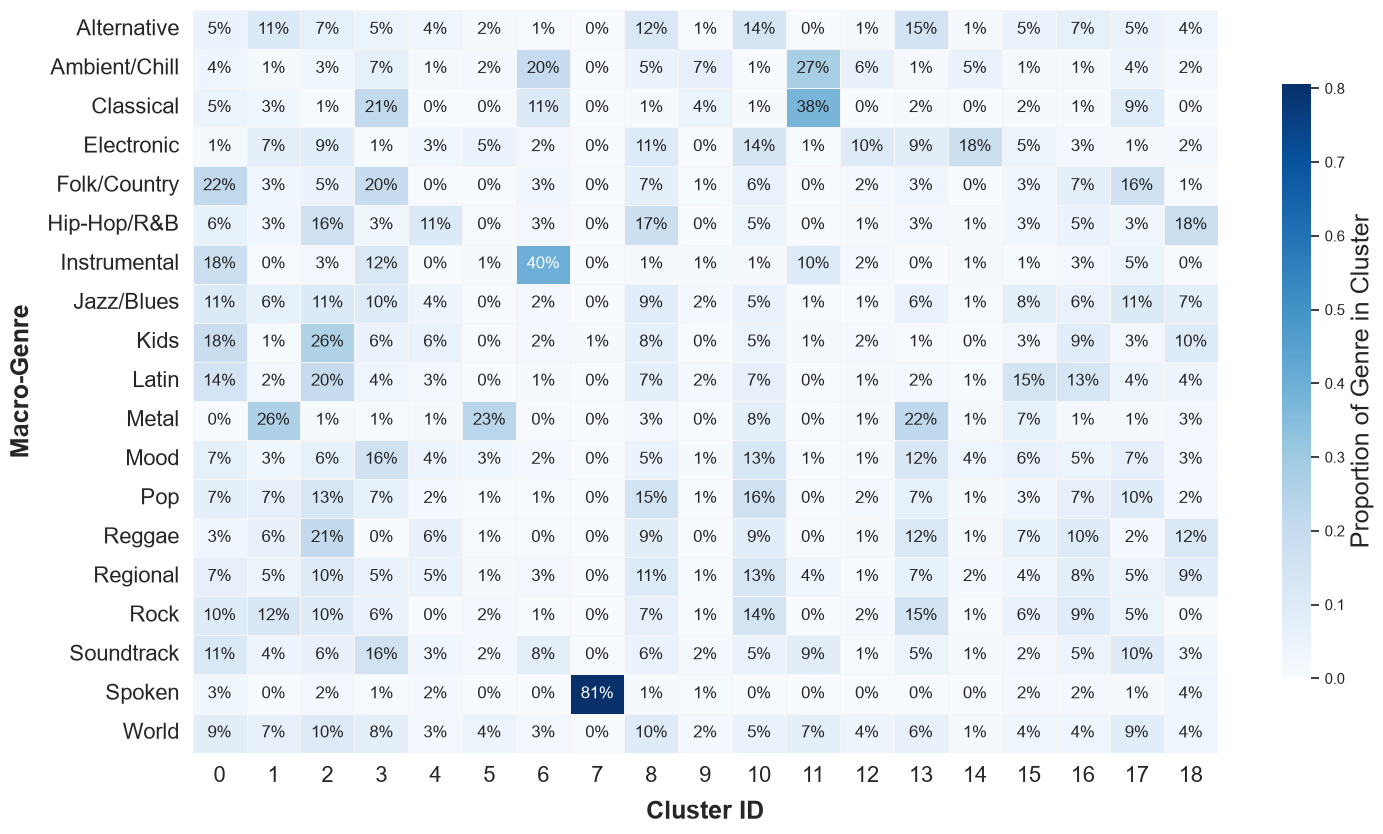

In [63]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

TITLE_SIZE = 20
LABEL_SIZE = 18
TICKS_SIZE = 16
ANNOT_SIZE = 12

# 1. Compute cross-tabulation (normalized by row/macro-genre)
genre_cluster = pd.crosstab(
    spotify["macro_genre"], spotify["cluster_19"], normalize="index"
)

# Set publication style
sns.set_theme(style="white")

# Adjust figure height dynamically based on the number of macro-genres
fig, ax = plt.subplots(figsize=(15, 8.5))

# Plot heatmap with annotated percentages
sns.heatmap(
    genre_cluster,
    annot=True,  # Display exact percentages inside cells
    fmt=".0%",  # Format as percentages (e.g., 25% instead of 0.25)
    cmap="Blues",
    vmin=0,
    vmax=genre_cluster.max().max(),  # Scale colors to peak concentration
    linewidths=0.5,
    linecolor="whitesmoke",
    cbar_kws={"shrink": 0.8, "label": "Proportion of Genre in Cluster"},
    annot_kws={"size": ANNOT_SIZE},  # Sized so numbers fit cleanly in 19 columns
    ax=ax,
)

cbar_axes = ax.collections[0].colorbar.ax

# Change the main colorbar title/label font size
cbar_axes.yaxis.label.set_size(LABEL_SIZE)

# Titles and Axis Labels
# ax.set_title(
#     "Macro-Genre Distribution Across $k=19$ Clusters (Row-Normalized)",
#     fontsize=TITLE_SIZE,
#     fontweight="bold",
#     pad=14,
# )
ax.set_xlabel("Cluster ID", fontsize=LABEL_SIZE, fontweight="bold", labelpad=10)
ax.set_ylabel("Macro-Genre", fontsize=LABEL_SIZE, fontweight="bold", labelpad=10)

# Format X-axis tick labels cleanly (Cluster 0 to Cluster 18)
ax.set_xticklabels(
    [f"{c}" for c in genre_cluster.columns], rotation=0, fontsize=TICKS_SIZE
)
ax.set_yticklabels(genre_cluster.index, rotation=0, fontsize=TICKS_SIZE)

plt.tight_layout()
plt.savefig("genre_cluster_cross_tab_k19.png", dpi=300, bbox_inches="tight")
plt.show()

# Try Isolating one Macro Genre at a time

The analysis is done only on songs with a fine grained genre, discarding songs where the genre is the same as Macro-Genre

In [70]:
vc = spotify['macro_genre'].value_counts()

print(vc)

macro_genre
Electronic       19481
Latin            11268
Hip-Hop/R&B      10289
Pop               9431
Rock              7936
Metal             6035
Ambient/Chill     5602
Regional          5499
World             5327
Folk/Country      4492
Soundtrack        3553
Alternative       3365
Mood              3003
Reggae            2600
Classical         2256
Jazz/Blues        2189
Kids              1827
Spoken             987
Instrumental       868
Name: count, dtype: int64


In [69]:
def compute_score_clustering(Ks, data):
  inertia = []
  silhouette = []

  for k in Ks:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init="auto"
    )

    labels = model.fit_predict(data)

    inertia.append(model.inertia_)

    silhouette.append(
        silhouette_score(data, labels)
    )

  
  # Create a figure with 1 row and 2 columns
  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

  # --- Left Graph: Silhouette Score ---
  ax1.plot(Ks, silhouette, marker="o", color="b")
  ax1.set_xlabel("K")
  ax1.set_ylabel("Silhouette Score")
  ax1.set_title("Choosing the Number of Clusters")
  ax1.grid(True, linestyle="--", alpha=0.6)  # Optional: adds a clean grid

  # --- Right Graph: Elbow Method (Inertia) ---
  ax2.plot(Ks, inertia, marker="o", color="r")
  ax2.set_xlabel("K")
  ax2.set_ylabel("Inertia")
  ax2.set_title("Elbow Method")
  ax2.grid(True, linestyle="--", alpha=0.6)  # Optional: adds a clean grid

  # Automatically adjust spacing so labels don't overlap
  plt.tight_layout()

  # Show the combined plot
  plt.show()

## Electronic Genre

In [ ]:
electronic_spotify = spotify[spotify['macro_genre'] == "Electronic"].copy()
electronic_spotify.drop(electronic_spotify[electronic_spotify['genre'] == 'electronic'].index, inplace=True)
electronic_spotify.reset_index(drop=True, inplace=True)
print(electronic_spotify.shape[0])

electronic_for_clustering = X_for_clustering[spotify['macro_genre'] == "Electronic"].copy()
electronic_for_clustering.drop(electronic_for_clustering[spotify['genre'] == 'electronic'].index, inplace=True)
electronic_for_clustering.reset_index(drop=True, inplace=True)
print(electronic_for_clustering.shape[0])

18673
18673


C:\Users\pietr\AppData\Local\Temp\ipykernel_24296\1030795332.py:7: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  electronic_for_clustering.drop(electronic_for_clustering[spotify['genre'] == 'electronic'].index, inplace=True)


In [67]:
vc = electronic_spotify['genre'].value_counts()

print(vc)

genre
edm                  4926
idm                   958
chicago-house         956
breakbeat             955
club                  946
detroit-techno        920
drum-and-bass         915
deep-house            915
hardstyle             880
garage                868
minimal-techno        845
industrial            809
disco                 769
progressive-house     677
trance                676
dance                 486
techno                401
electro               384
dubstep               253
house                 134
Name: count, dtype: int64


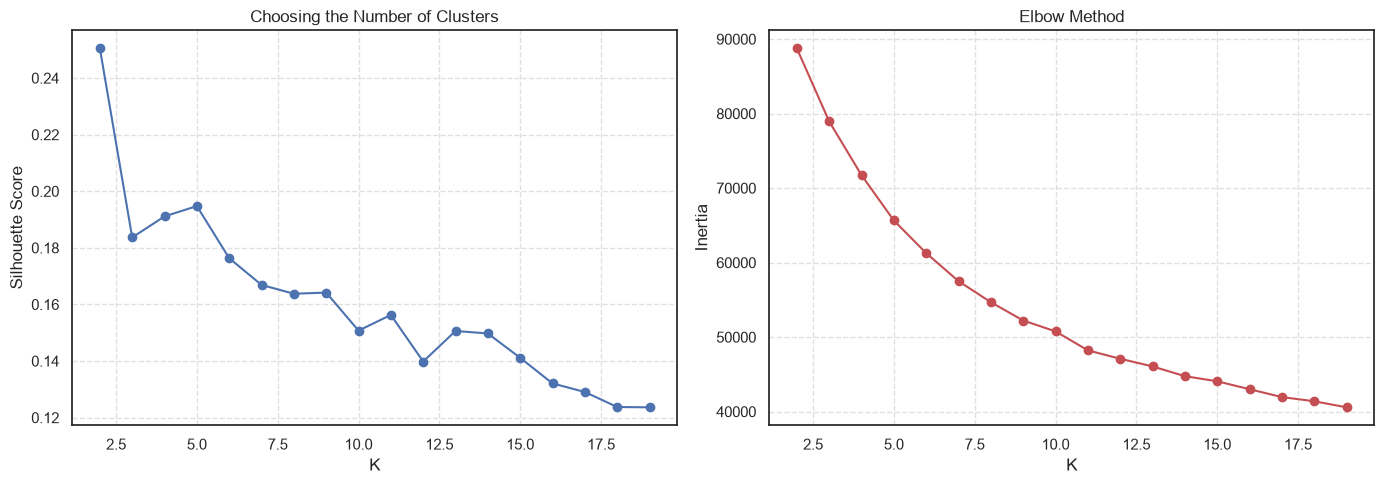

In [74]:
compute_score_clustering(range(2, 20), electronic_for_clustering)

In [72]:
latin_spotify = spotify[spotify['macro_genre'] == "Latin"].copy()
latin_spotify.drop(latin_spotify[latin_spotify['genre'] == 'latino'].index, inplace=True)
latin_spotify.drop(latin_spotify[latin_spotify['genre'] == 'latin'].index, inplace=True)
latin_spotify.reset_index(drop=True, inplace=True)
print(latin_spotify.shape[0])

latin_for_clustering = X_for_clustering[spotify['macro_genre'] == "Latin"].copy()
latin_for_clustering.drop(latin_for_clustering[spotify['genre'] == 'latino'].index, inplace=True)
latin_for_clustering.drop(latin_for_clustering[spotify['genre'] == 'latin'].index, inplace=True)
latin_for_clustering.reset_index(drop=True, inplace=True)
print(latin_for_clustering.shape[0])

6806
6806


C:\Users\pietr\AppData\Local\Temp\ipykernel_24296\504424834.py:8: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  latin_for_clustering.drop(latin_for_clustering[spotify['genre'] == 'latino'].index, inplace=True)
C:\Users\pietr\AppData\Local\Temp\ipykernel_24296\504424834.py:9: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  latin_for_clustering.drop(latin_for_clustering[spotify['genre'] == 'latin'].index, inplace=True)


In [73]:
vc = latin_spotify['genre'].value_counts()
print(vc)

genre
forro        968
tango        935
brazil       928
salsa        926
pagode       819
sertanejo    803
mpb          754
samba        610
reggaeton     63
Name: count, dtype: int64


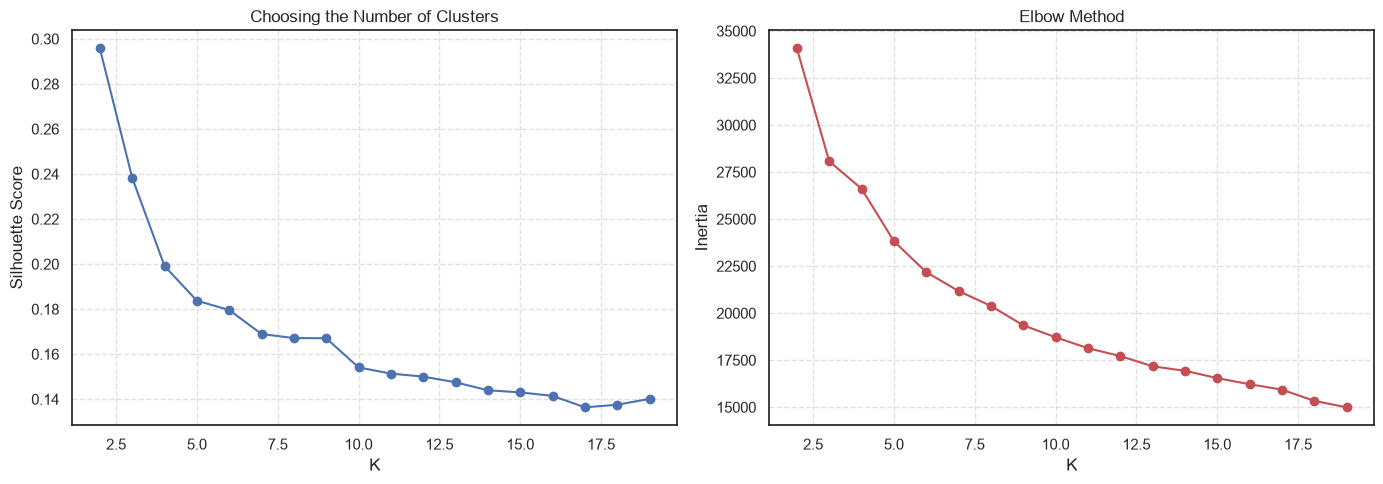

In [76]:
compute_score_clustering(range(2, 20), latin_for_clustering)

In [77]:
pop_spotify = spotify[spotify['macro_genre'] == "Pop"].copy()
pop_spotify.drop(pop_spotify[pop_spotify['genre'] == 'popo'].index, inplace=True)
pop_spotify.drop(pop_spotify[pop_spotify['genre'] == 'pop'].index, inplace=True)
pop_spotify.reset_index(drop=True, inplace=True)
print(pop_spotify.shape[0])

pop_for_clustering = X_for_clustering[spotify['macro_genre'] == "Pop"].copy()
pop_for_clustering.drop(pop_for_clustering[spotify['genre'] == 'popo'].index, inplace=True)
pop_for_clustering.drop(pop_for_clustering[spotify['genre'] == 'pop'].index, inplace=True)
pop_for_clustering.reset_index(drop=True, inplace=True)
print(pop_for_clustering.shape[0])

4787
4787


C:\Users\pietr\AppData\Local\Temp\ipykernel_24296\3580681720.py:8: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  pop_for_clustering.drop(pop_for_clustering[spotify['genre'] == 'popo'].index, inplace=True)
C:\Users\pietr\AppData\Local\Temp\ipykernel_24296\3580681720.py:9: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  pop_for_clustering.drop(pop_for_clustering[spotify['genre'] == 'pop'].index, inplace=True)


In [78]:
vc = pop_spotify['genre'].value_counts()
print(vc)

genre
cantopop     955
k-pop        854
mandopop     843
power-pop    833
synth-pop    708
j-pop        594
Name: count, dtype: int64


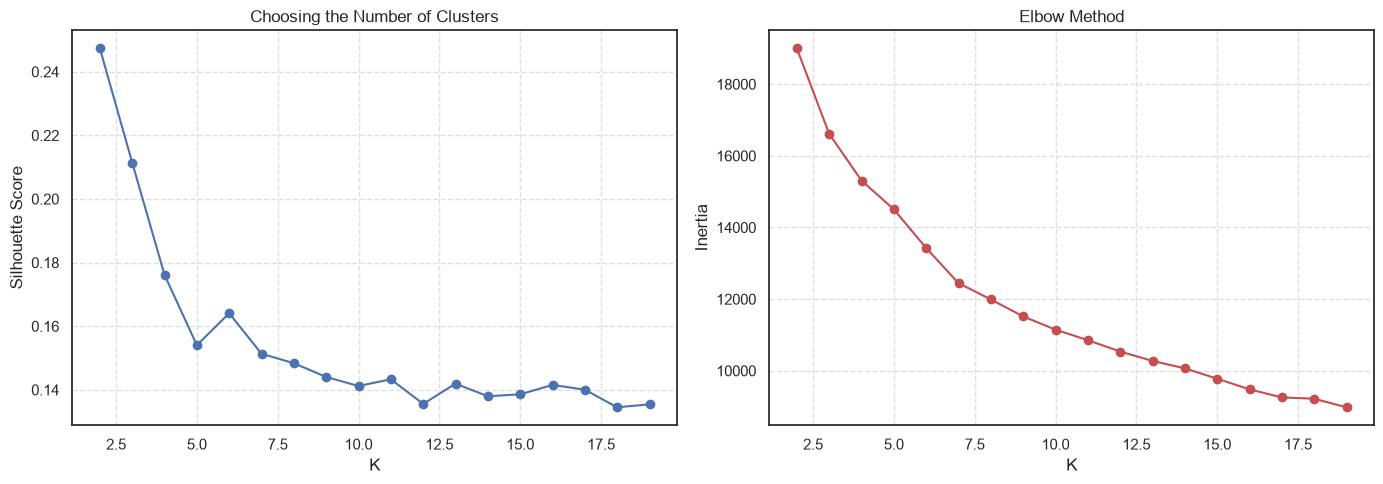

In [79]:
compute_score_clustering(range(2, 20), pop_for_clustering)

In [ ]:
###############################

def run_kmeans_and_plot(num_clusters, X_for_clustering, spotify, genre_column="macro_genre"):
  kmeans = KMeans(
      n_clusters=num_clusters,
      random_state=42,
      n_init="auto"
  )

  clusters = kmeans.fit_predict(X_for_clustering)

  spotify["cluster"] = clusters

  cluster_profile = (
      spotify.groupby("cluster")[X_for_clustering.columns]
        .mean()
        .round(2)
  )

  display(cluster_profile)

  plt.figure(figsize=(14,6))

  sns.heatmap(
      cluster_profile,
      cmap="coolwarm",
      annot=True
  )

  plt.title("Average Audio Features by Cluster")

  plt.show()


  genre_cluster = pd.crosstab(
      spotify[genre_column],
      spotify["cluster"],
      normalize="index"
  )

  display(genre_cluster)

  plt.figure(figsize=(12,10))

  sns.heatmap(
      genre_cluster,
      cmap="Blues"
  )

  plt.title("Genre Distribution Across Clusters")

  plt.show()


##########################

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
cluster,,,,,,,,,
0,0.51,0.59,0.07,-0.23,-0.78,2.02,-0.35,-0.45,0.28
1,0.80,0.42,0.37,-0.07,-0.55,-0.35,-0.29,0.67,-0.03
2,-0.20,0.72,0.64,-0.05,-0.72,-0.33,-0.18,-0.72,0.45
3,-0.31,-1.06,-1.23,-0.31,0.73,1.33,-0.38,-0.93,-0.22
4,0.04,0.84,0.57,0.14,-0.72,0.27,2.10,-0.32,0.34


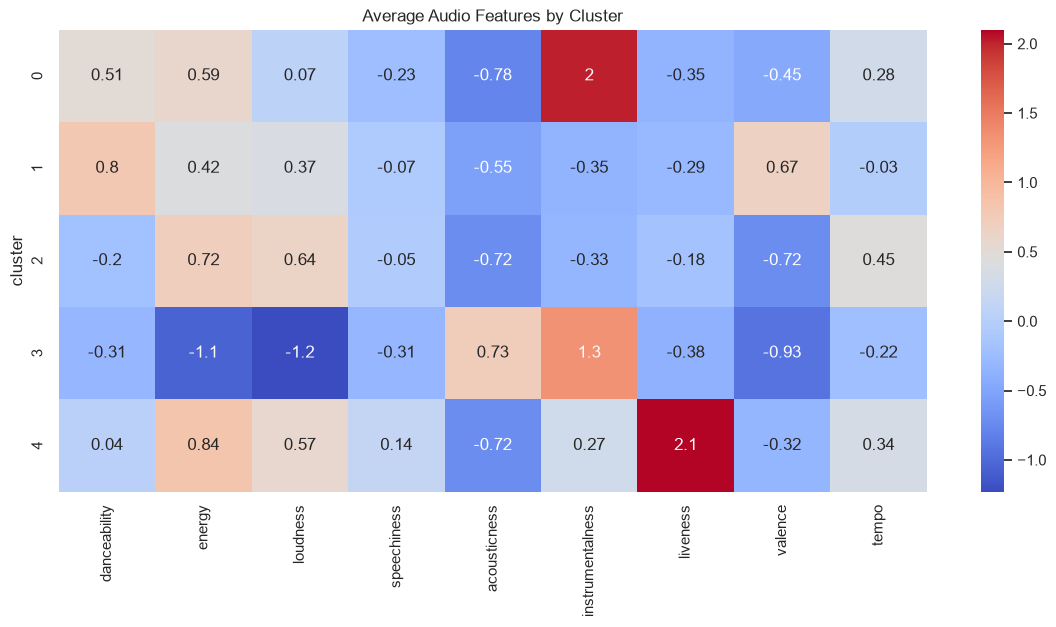

cluster,0,1,2,3,4
genre,,,,,
breakbeat,0.375916,0.282723,0.204188,0.012565,0.124607
chicago-house,0.494770,0.407950,0.039749,0.019874,0.037657
club,0.347780,0.243129,0.234672,0.099366,0.075053
dance,0.010288,0.670782,0.271605,0.016461,0.030864
deep-house,0.233880,0.481967,0.205464,0.032787,0.045902
detroit-techno,0.668478,0.145652,0.020652,0.120652,0.044565
disco,0.046814,0.713914,0.111834,0.079324,0.048114
drum-and-bass,0.332240,0.085246,0.449180,0.003279,0.130055
dubstep,0.102767,0.063241,0.707510,0.035573,0.090909


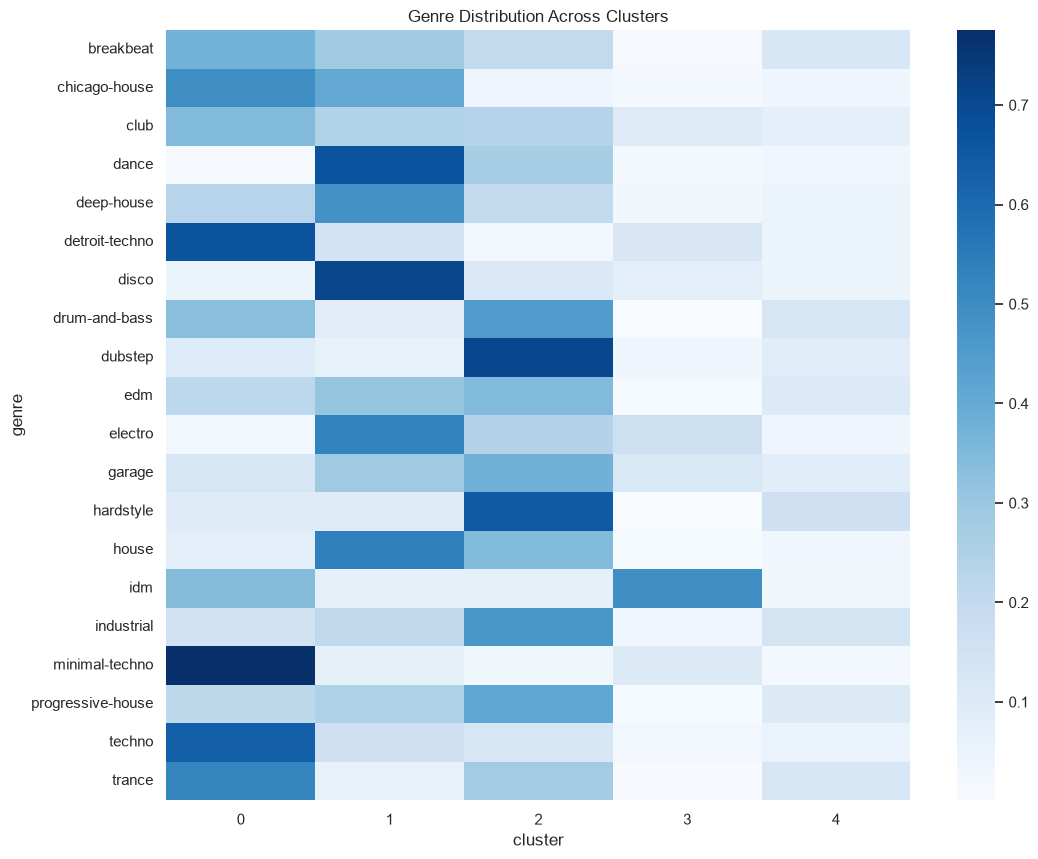

In [81]:
run_kmeans_and_plot(5, electronic_for_clustering, electronic_spotify, genre_column="genre")

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
cluster,,,,,,,,,
0,0.57,0.30,0.32,-0.13,0.27,-0.48,-0.11,1.10,-0.63
1,-0.57,-0.31,-0.07,-0.30,0.76,-0.49,2.70,-0.11,-0.47
2,0.12,0.39,0.42,-0.23,0.35,-0.51,-0.05,1.03,1.29
3,-0.08,0.57,0.39,-0.11,0.49,-0.51,3.14,0.87,0.29
4,-0.20,-1.06,-0.39,-0.26,1.34,-0.26,-0.25,0.06,-0.24


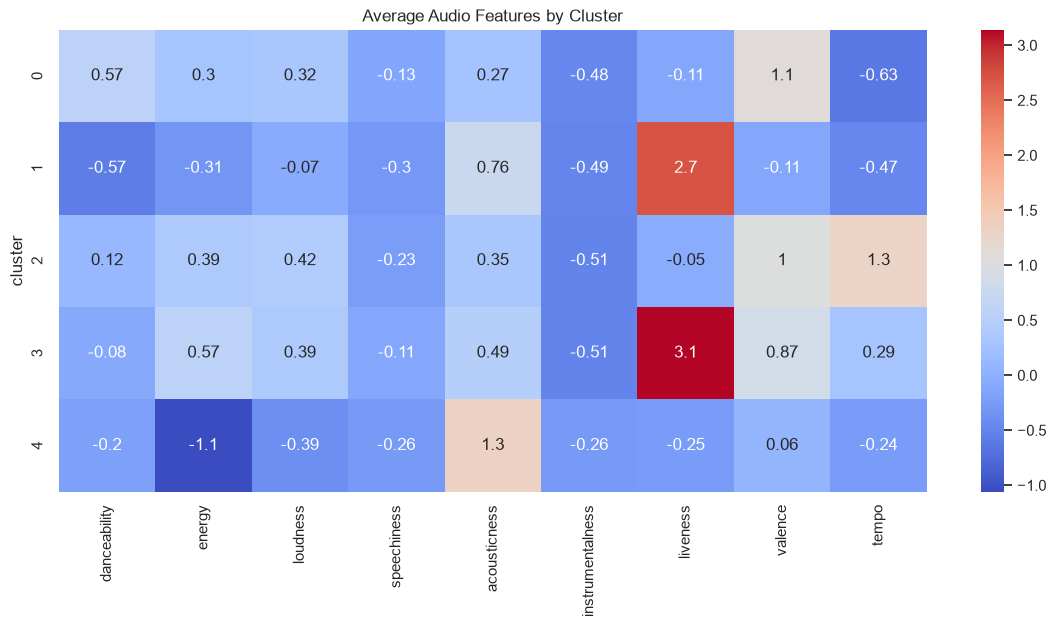

cluster,0,1,2,3,4
genre,,,,,
brazil,0.286638,0.140086,0.190733,0.064655,0.317888
forro,0.288223,0.023760,0.519628,0.144628,0.023760
mpb,0.221485,0.181698,0.144562,0.123342,0.328912
pagode,0.183150,0.126984,0.213675,0.410256,0.065934
reggaeton,0.682540,0.000000,0.269841,0.015873,0.031746
salsa,0.591793,0.009719,0.280778,0.042117,0.075594
samba,0.311475,0.132787,0.173770,0.298361,0.083607
sertanejo,0.245330,0.127024,0.211706,0.297634,0.118306
tango,0.044920,0.090909,0.028877,0.006417,0.828877


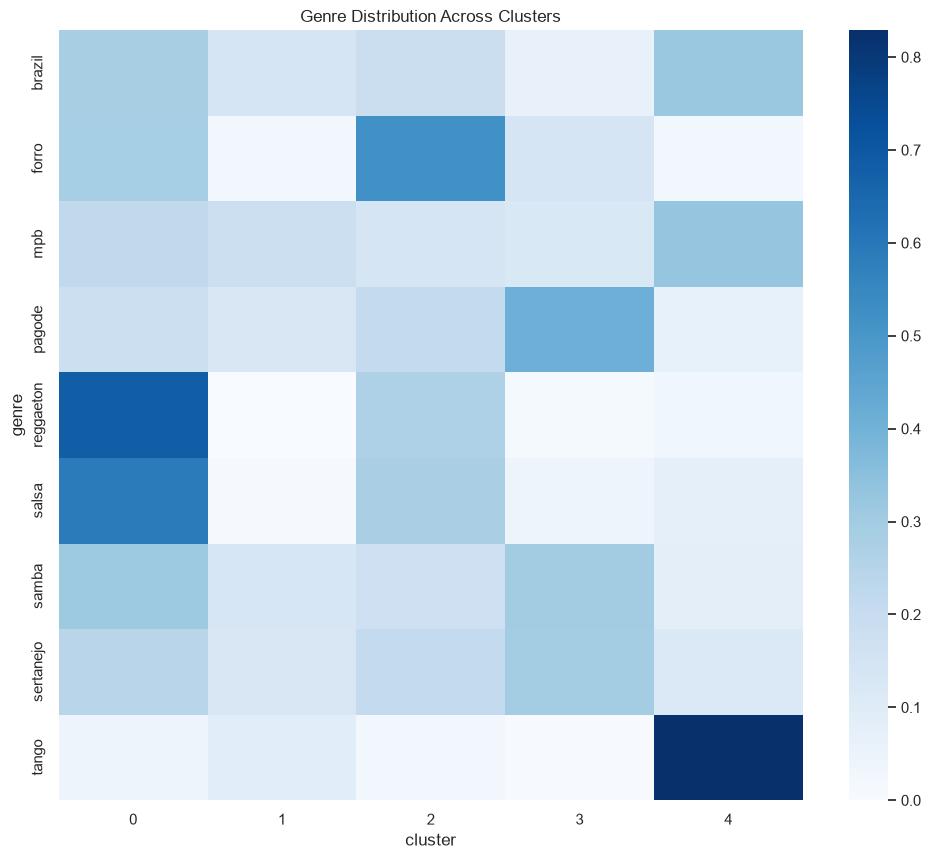

In [82]:
run_kmeans_and_plot(5, latin_for_clustering, latin_spotify, genre_column="genre")

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
cluster,,,,,,,,,
0,-0.33,-1.12,-0.42,-0.50,1.29,-0.48,-0.23,-0.56,-0.00
1,-0.88,0.71,0.49,-0.11,-0.59,-0.34,0.17,0.33,1.44
2,0.52,-0.20,-0.20,-0.33,0.23,-0.42,-0.32,0.95,-0.07
3,0.28,0.78,0.62,-0.25,-0.66,-0.42,-0.04,0.78,-0.20
4,-0.17,-0.17,0.15,-0.45,-0.27,-0.41,-0.18,-0.61,-0.35


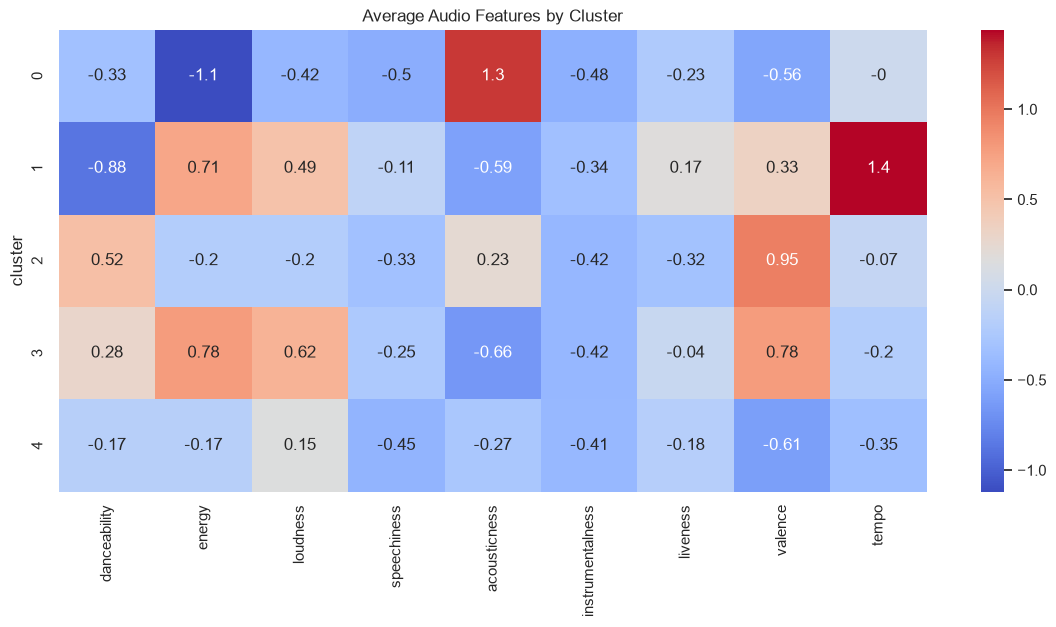

cluster,0,1,2,3,4
genre,,,,,
cantopop,0.584293,0.062827,0.131937,0.032461,0.188482
j-pop,0.191919,0.178451,0.146465,0.345118,0.138047
k-pop,0.142857,0.101874,0.238876,0.373536,0.142857
mandopop,0.455516,0.084223,0.094899,0.062871,0.302491
power-pop,0.040816,0.418968,0.112845,0.316927,0.110444
synth-pop,0.052260,0.124294,0.209040,0.341808,0.272599


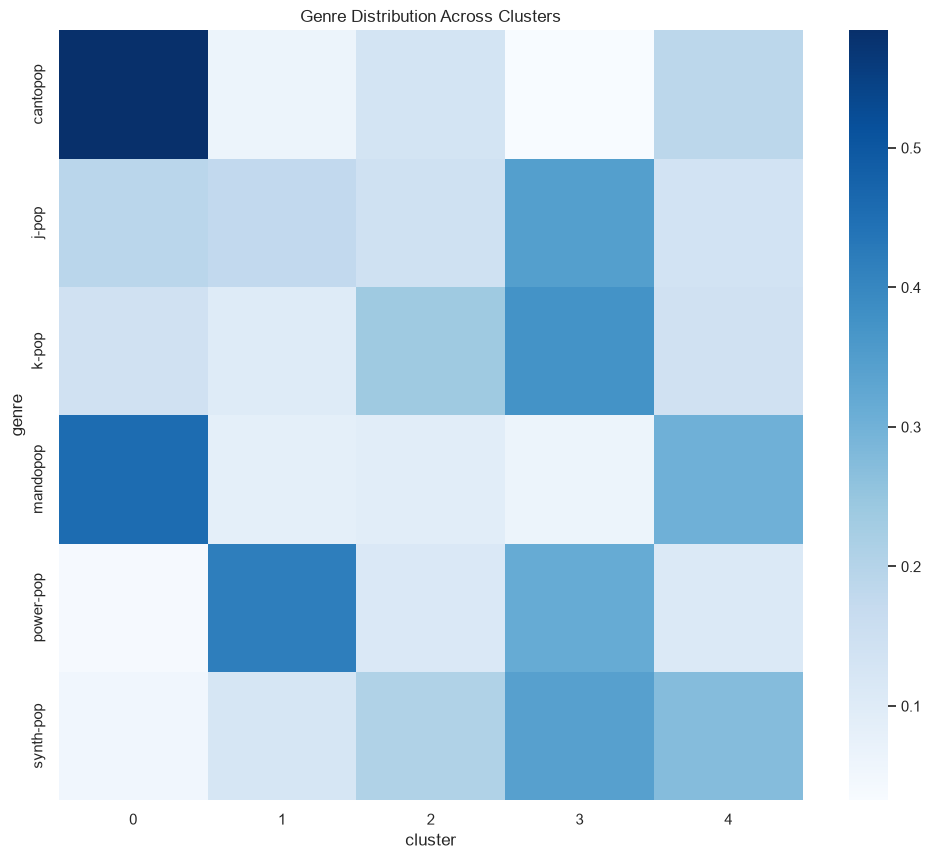

In [83]:
run_kmeans_and_plot(5, pop_for_clustering, pop_spotify, genre_column="genre")

C:\Users\pietr\AppData\Local\Temp\ipykernel_24296\645666974.py:150: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


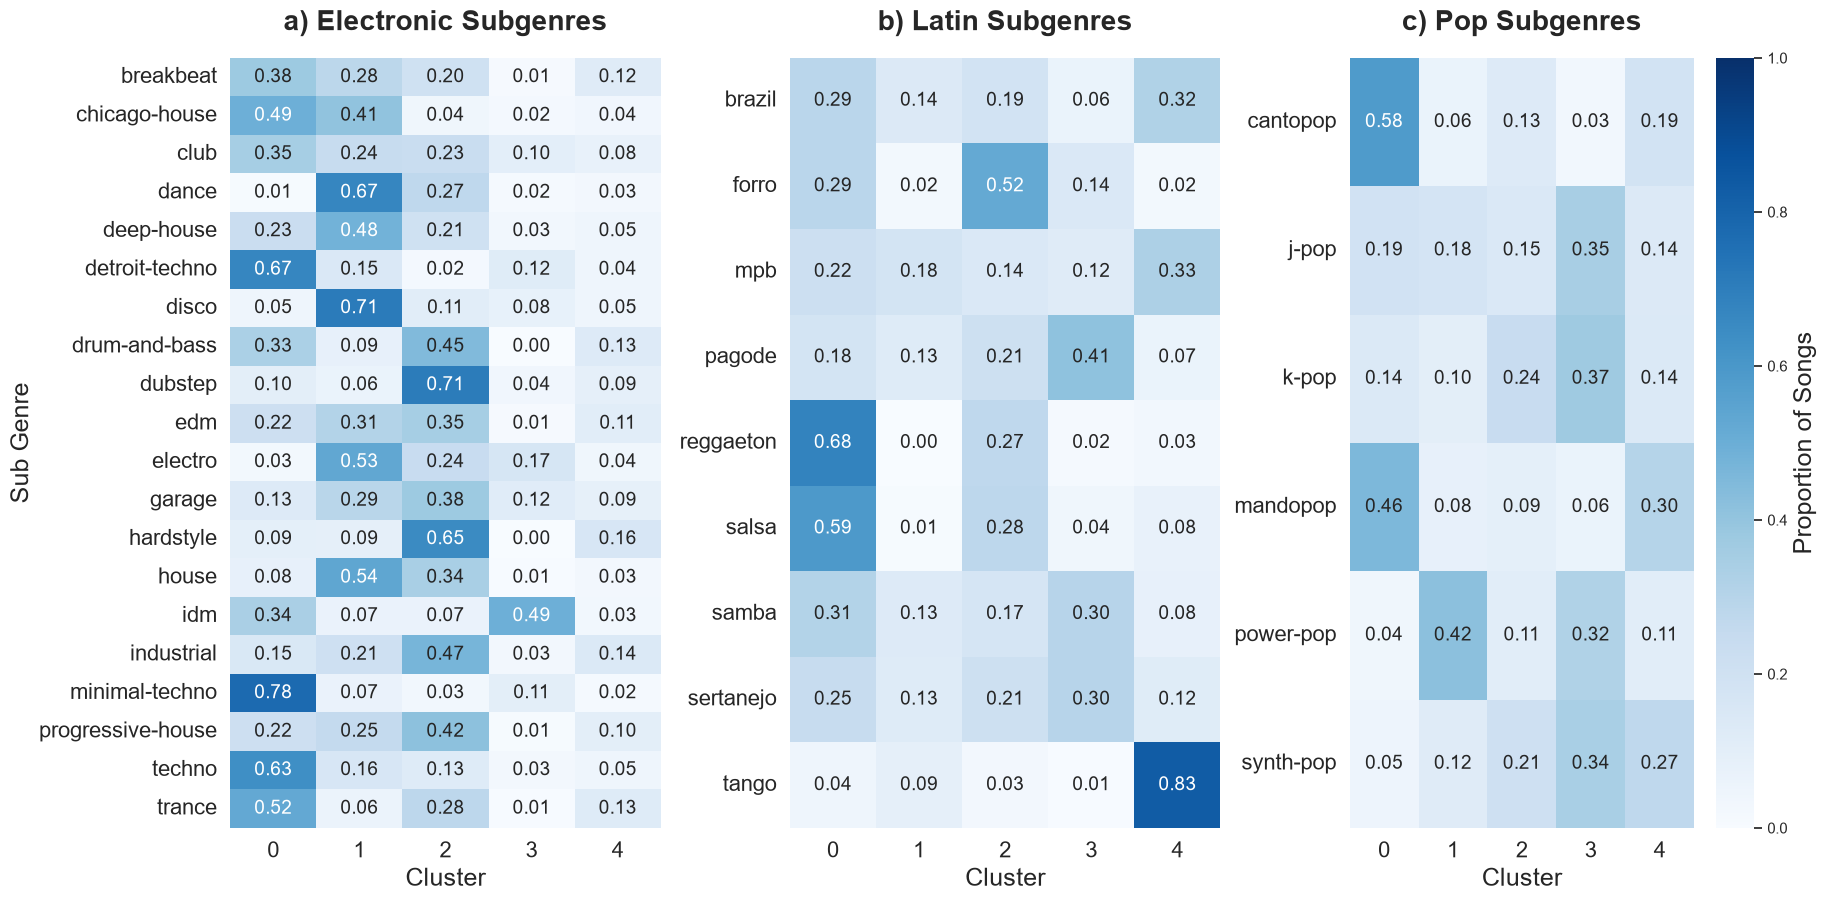

In [95]:
TITLE_SIZE = 20
LABEL_SIZE = 18
TICKS_SIZE = 16
ANNOT_SIZE = 14

# Compute both normalized cross-tabs
electronic_genre_cluster = pd.crosstab(
    electronic_spotify["genre"],    
    electronic_spotify["cluster"],
    normalize="index"
)

latin_genre_cluster = pd.crosstab(
    latin_spotify["genre"],
    latin_spotify["cluster"],
    normalize="index"
)

pop_genre_cluster = pd.crosstab(
    pop_spotify["genre"],
    pop_spotify["cluster"],
    normalize="index"
)


# Create figure
fig, axes = plt.subplots(
    1, 3,
    figsize=(20, 10),
    gridspec_kw={
        "width_ratios": [1, 1, 1],
        "wspace": 0.30
    }
)

# Electronic genre heatmap
sns.heatmap(
    electronic_genre_cluster,
    cmap="Blues",
    annot=True,
    fmt=".2f",
    vmin=0,
    vmax=1,
    annot_kws={"size": ANNOT_SIZE},
    cbar=False,
    ax=axes[0]
)

axes[0].set_title(
    "a) Electronic Subgenres",
    fontsize=TITLE_SIZE,
    fontweight="bold",
    pad=20
)

axes[0].set_xlabel(
    "Cluster",
    fontsize=LABEL_SIZE
)

axes[0].set_ylabel(
    "Sub Genre",
    fontsize=LABEL_SIZE
)

axes[0].tick_params(
    axis="both",
    labelsize=TICKS_SIZE
)


# Latin genre heatmap
ax = sns.heatmap(
    latin_genre_cluster,
    cmap="Blues",
    annot=True,
    fmt=".2f",
    vmin=0,
    vmax=1,
    annot_kws={"size": ANNOT_SIZE},
    cbar=False,
    ax=axes[1]
)

axes[1].set_title(
    "b) Latin Subgenres",
    fontsize=TITLE_SIZE,
    fontweight="bold",
    pad=20
)

axes[1].set_xlabel(
    "Cluster",
    fontsize=LABEL_SIZE
)

axes[1].set_ylabel("")

axes[1].tick_params(
    axis="both",
    labelsize=TICKS_SIZE
)

# Pop genre heatmap
ax = sns.heatmap(
    pop_genre_cluster,
    cmap="Blues",
    annot=True,
    fmt=".2f",
    vmin=0,
    vmax=1,
    annot_kws={"size": ANNOT_SIZE},
    cbar_kws={"label": "Proportion of Songs"},
    ax=axes[2]
)

axes[2].set_title(
    "c) Pop Subgenres",
    fontsize=TITLE_SIZE,
    fontweight="bold",
    pad=20
)

axes[2].set_xlabel(
    "Cluster",
    fontsize=LABEL_SIZE
)

axes[2].set_ylabel("")

axes[2].tick_params(
    axis="both",
    labelsize=TICKS_SIZE
)

cbar_axes = ax.collections[0].colorbar.ax

# Change the main colorbar title/label font size
cbar_axes.yaxis.label.set_size(LABEL_SIZE)

for ax in axes:
    ax.tick_params(
        axis="both",
        labelsize=TICKS_SIZE
    )
    ax.tick_params(axis="y", labelrotation=0)
    ax.tick_params(axis="x", labelrotation=0)


plt.tight_layout()

plt.savefig(
    "subgenre_heatmaps.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
cluster,,,,,,,,,
0,-0.42,0.94,0.67,-0.02,-0.80,1.85,-0.17,-0.65,1.66
1,1.11,-0.15,-0.27,-0.18,-0.50,-0.33,-0.45,1.06,-0.08
2,1.10,-0.19,-0.67,-0.13,-0.69,2.04,-0.51,0.59,0.08
3,0.16,0.85,0.33,-0.15,-0.82,1.88,2.07,-0.61,0.28
4,0.17,0.81,0.69,-0.25,-0.77,-0.35,-0.45,-0.77,0.20
5,0.68,0.92,0.28,-0.28,-0.80,1.91,-0.37,0.89,0.20
6,0.58,0.82,0.63,-0.13,-0.67,-0.40,0.73,0.82,0.18
7,-0.07,-0.86,-0.36,-0.32,0.98,-0.38,-0.25,-0.47,-0.21
8,-0.42,0.93,0.38,-0.27,-0.82,1.89,-0.17,-1.12,0.11


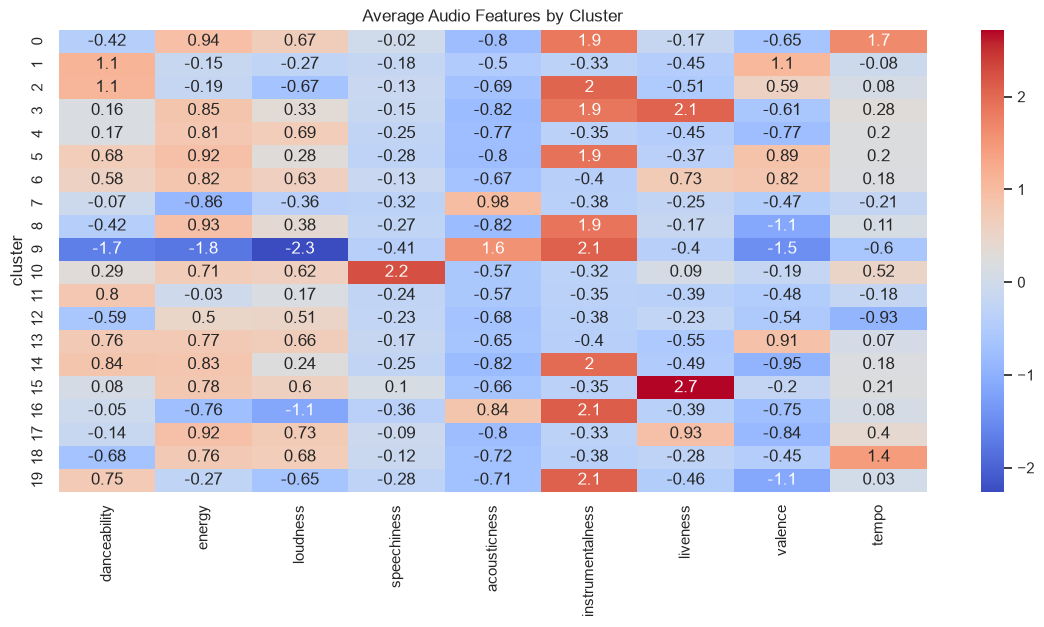

cluster,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
genre,,,,,,,,,,,,,,,,,,,,
breakbeat,0.067016,0.029319,0.024084,0.056545,0.076440,0.127749,0.085864,0.002094,0.071204,0.000000,0.031414,0.046073,0.024084,0.110995,0.085864,0.035602,0.007330,0.037696,0.060733,0.019895
chicago-house,0.003138,0.173640,0.198745,0.016736,0.028243,0.171548,0.047071,0.000000,0.005230,0.000000,0.014644,0.060669,0.001046,0.107741,0.084728,0.009414,0.001046,0.006276,0.003138,0.066946
club,0.051797,0.025370,0.012685,0.033827,0.059197,0.047569,0.041226,0.083510,0.119450,0.012685,0.079281,0.067653,0.063425,0.070825,0.070825,0.028541,0.016913,0.024313,0.044397,0.046512
dance,0.000000,0.090535,0.000000,0.000000,0.076132,0.002058,0.084362,0.059671,0.006173,0.000000,0.043210,0.211934,0.061728,0.248971,0.004115,0.016461,0.000000,0.028807,0.065844,0.000000
deep-house,0.002186,0.068852,0.031694,0.008743,0.091803,0.054645,0.067760,0.019672,0.028415,0.000000,0.009836,0.218579,0.019672,0.170492,0.074317,0.020765,0.012022,0.030601,0.010929,0.059016
detroit-techno,0.005435,0.058696,0.202174,0.032609,0.010870,0.172826,0.010870,0.005435,0.035870,0.000000,0.009783,0.028261,0.002174,0.035870,0.121739,0.014130,0.042391,0.002174,0.002174,0.206522
disco,0.001300,0.211964,0.007802,0.002601,0.036411,0.029909,0.192458,0.111834,0.003901,0.000000,0.015605,0.041612,0.018205,0.244473,0.010403,0.026008,0.001300,0.014304,0.020806,0.009103
drum-and-bass,0.315847,0.008743,0.005464,0.044809,0.024044,0.034973,0.021858,0.000000,0.030601,0.000000,0.045902,0.013115,0.067760,0.026230,0.014208,0.030601,0.001093,0.037158,0.275410,0.002186
dubstep,0.055336,0.003953,0.000000,0.015810,0.181818,0.003953,0.019763,0.031621,0.031621,0.003953,0.098814,0.035573,0.142292,0.023715,0.019763,0.039526,0.003953,0.094862,0.181818,0.011858


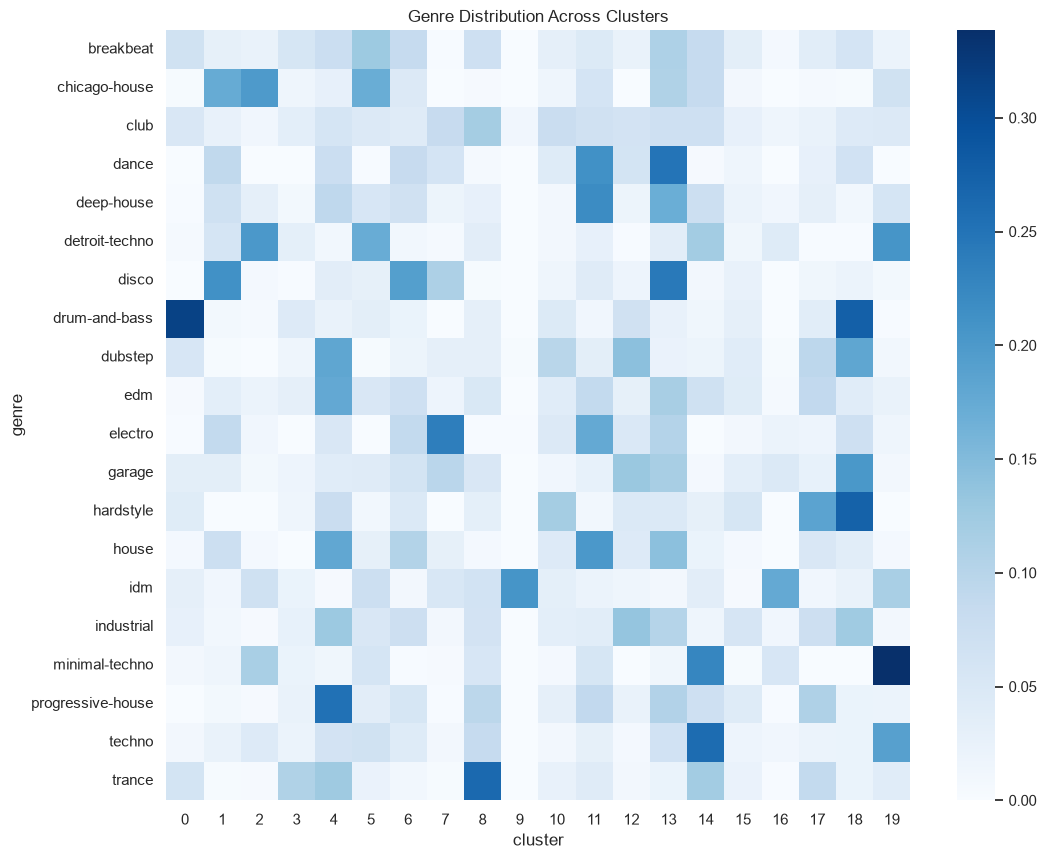

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
cluster,,,,,,,,,
0,0.30,-0.52,-0.09,-0.29,1.32,-0.34,-0.11,1.05,-0.34
1,0.06,0.53,0.35,-0.16,0.51,-0.51,3.06,0.88,-0.62
2,-0.39,0.50,0.40,-0.15,0.47,-0.51,3.07,0.65,1.17
3,-0.41,-1.42,-0.68,-0.34,1.62,-0.17,-0.28,-0.22,-0.31
4,0.56,-0.13,0.05,2.23,0.44,-0.48,-0.00,0.63,-0.42
5,0.20,0.48,0.45,-0.26,0.39,-0.51,-0.11,1.24,1.43
6,0.68,0.50,0.45,-0.29,0.10,-0.49,-0.17,1.25,-0.56
7,-0.62,-0.57,-0.24,-0.33,0.92,-0.49,2.81,-0.26,-0.36
8,-0.38,-0.18,0.21,-0.41,0.02,-0.49,-0.02,-0.39,0.05


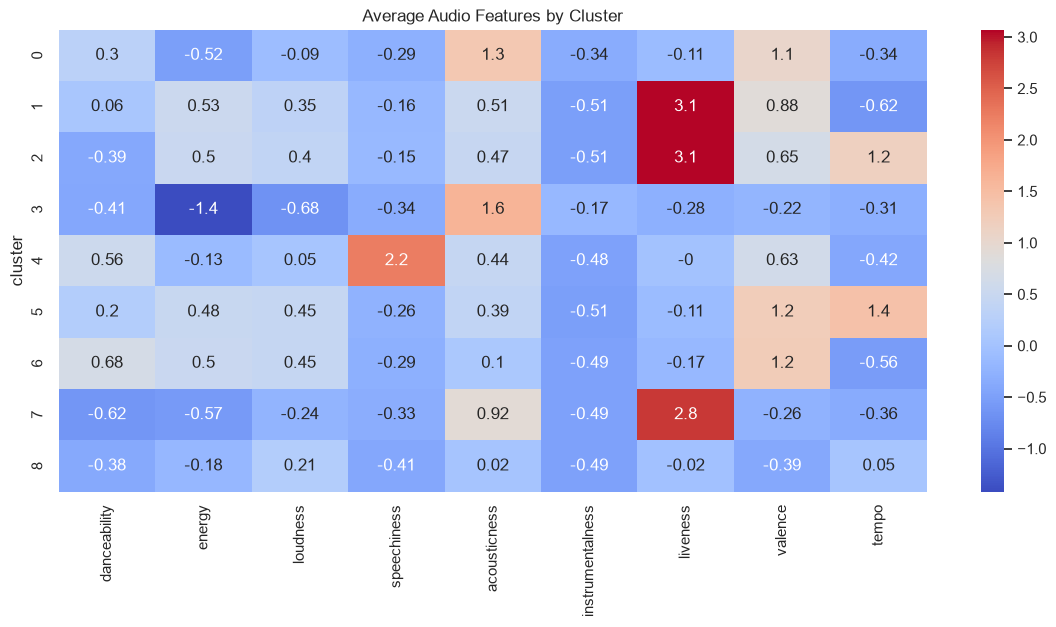

cluster,0,1,2,3,4,5,6,7,8
genre,,,,,,,,,
brazil,0.035560,0.037716,0.043103,0.098060,0.130388,0.075431,0.133621,0.104526,0.341595
forro,0.063017,0.080579,0.090909,0.003099,0.007231,0.447314,0.252066,0.011364,0.044421
mpb,0.127321,0.112732,0.058355,0.176393,0.019894,0.088859,0.143236,0.119363,0.153846
pagode,0.137973,0.223443,0.262515,0.013431,0.004884,0.151404,0.097680,0.061050,0.047619
reggaeton,0.000000,0.015873,0.000000,0.000000,0.206349,0.206349,0.492063,0.000000,0.079365
salsa,0.186825,0.041037,0.006479,0.017279,0.009719,0.261339,0.440605,0.004320,0.032397
samba,0.137705,0.250820,0.095082,0.040984,0.040984,0.137705,0.173770,0.070492,0.052459
sertanejo,0.112080,0.209215,0.145704,0.033624,0.002491,0.155666,0.156912,0.067248,0.117061
tango,0.347594,0.004278,0.004278,0.494118,0.024599,0.013904,0.005348,0.083422,0.022460


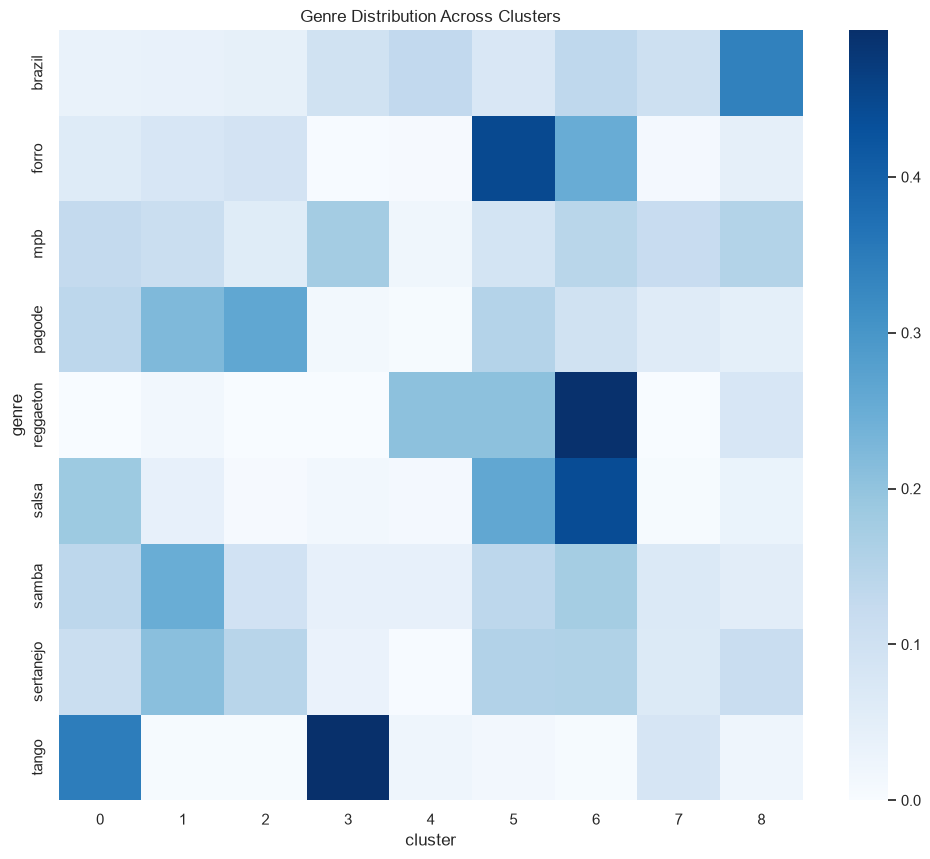

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
cluster,,,,,,,,,
0,-0.32,-1.12,-0.40,-0.51,1.29,-0.48,-0.31,-0.58,-0.01
1,-0.85,0.69,0.50,-0.10,-0.57,-0.35,-0.08,0.38,1.49
2,-0.51,0.21,0.04,-0.23,-0.25,-0.35,2.40,-0.07,0.10
3,0.33,0.77,0.61,-0.25,-0.65,-0.43,-0.16,0.83,-0.18
4,-0.16,-0.15,0.19,-0.45,-0.29,-0.41,-0.32,-0.59,-0.34
5,0.51,-0.25,-0.23,-0.36,0.27,-0.41,-0.33,0.93,-0.10


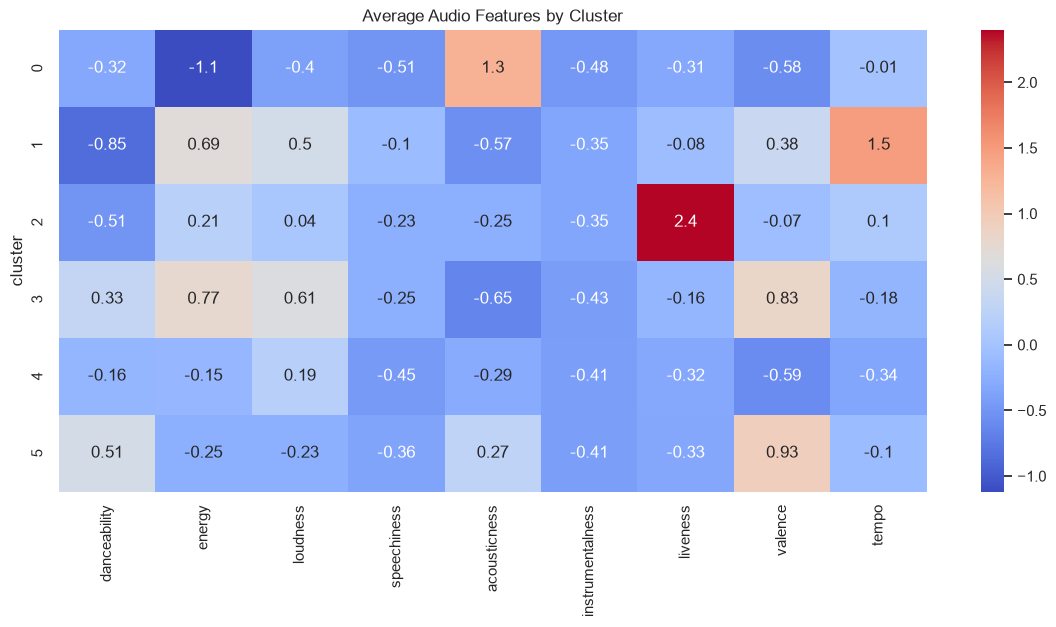

cluster,0,1,2,3,4,5
genre,,,,,,
cantopop,0.557068,0.052356,0.058639,0.032461,0.171728,0.127749
j-pop,0.183502,0.164983,0.031987,0.340067,0.141414,0.138047
k-pop,0.138173,0.103044,0.031616,0.368852,0.144028,0.214286
mandopop,0.454330,0.086595,0.018980,0.059312,0.291815,0.088968
power-pop,0.037215,0.379352,0.073229,0.292917,0.110444,0.106843
synth-pop,0.049435,0.111582,0.057910,0.327684,0.262712,0.190678


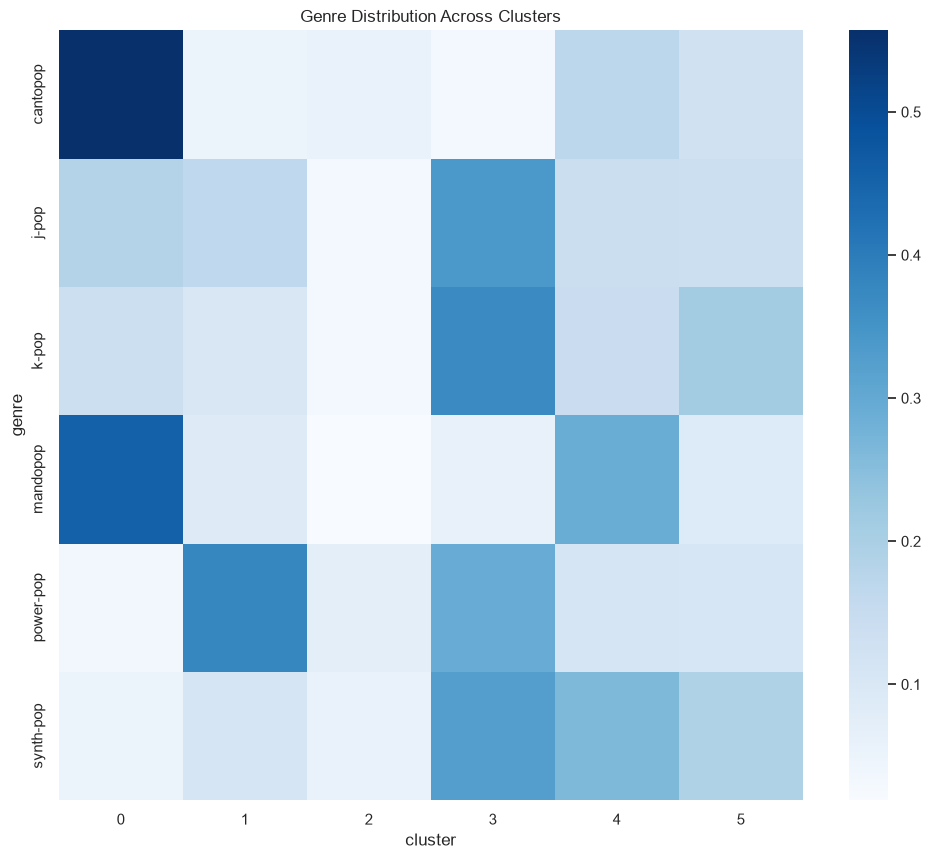

In [96]:
run_kmeans_and_plot(20, electronic_for_clustering, electronic_spotify, genre_column="genre")
run_kmeans_and_plot(9, latin_for_clustering, latin_spotify, genre_column="genre")
run_kmeans_and_plot(6, pop_for_clustering, pop_spotify, genre_column="genre")

C:\Users\pietr\AppData\Local\Temp\ipykernel_24296\2685664258.py:183: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


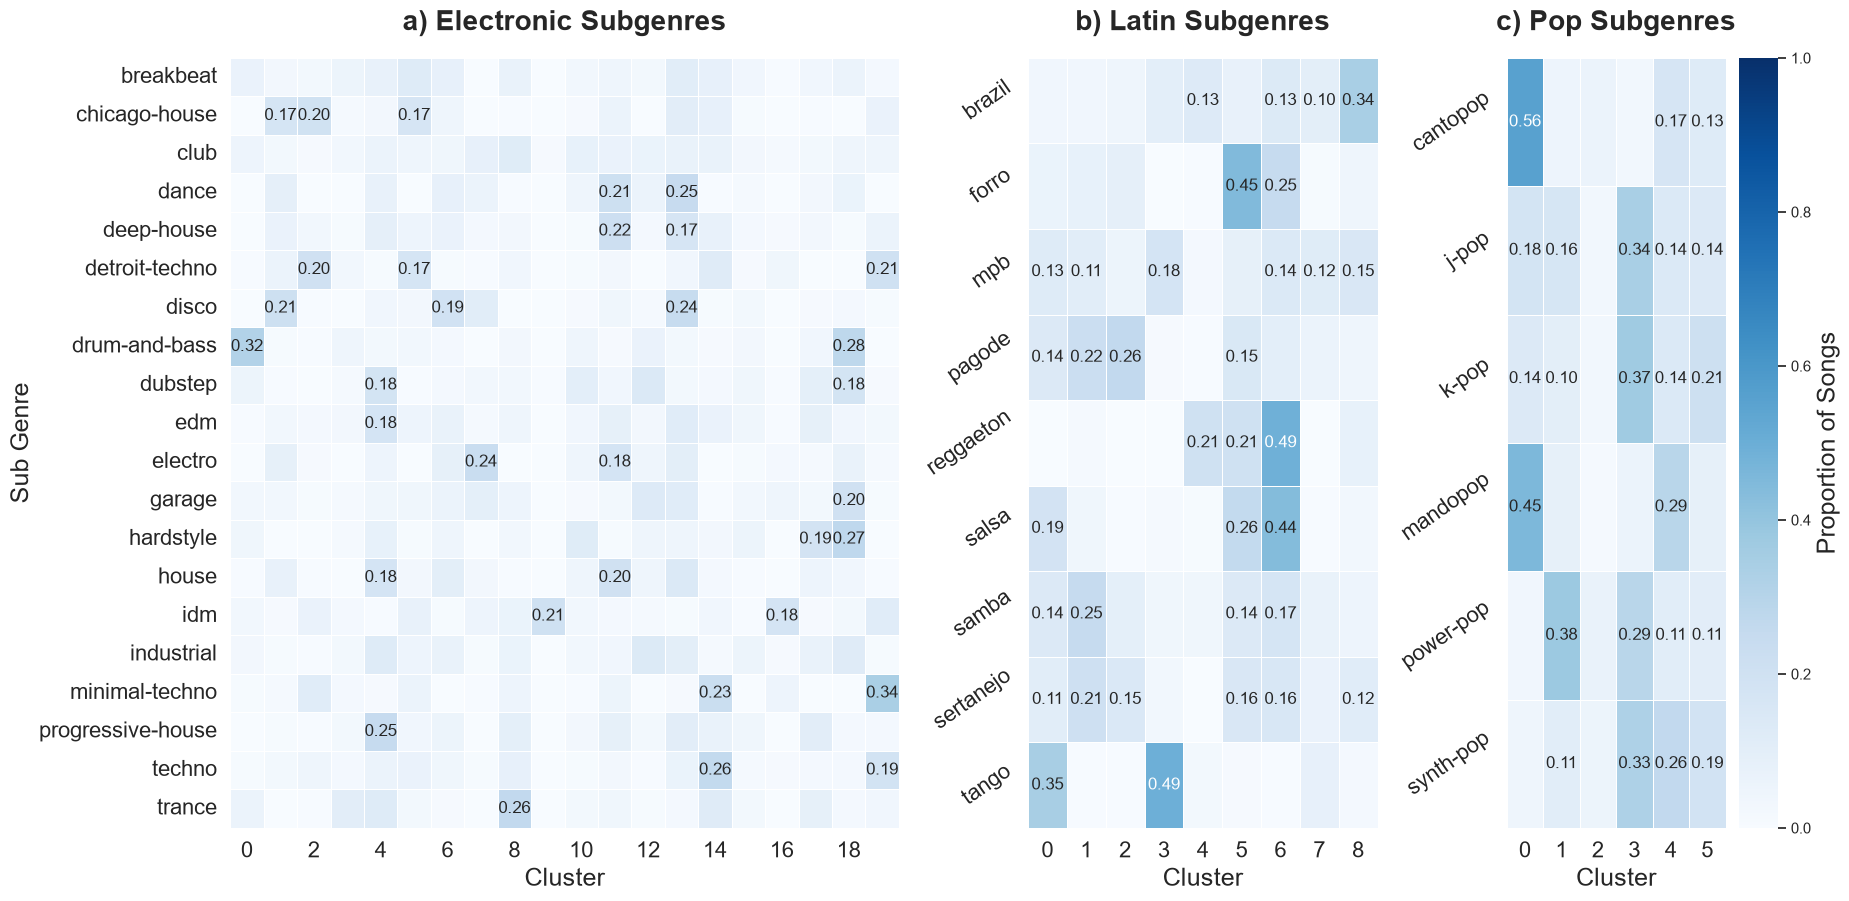

In [123]:
TITLE_SIZE = 20
LABEL_SIZE = 18
TICKS_SIZE = 16
ANNOT_SIZE = 12

def annotation_matrix(df, threshold=0.10):
    return df.map(
        lambda x: f"{x:.2f}" if x >= threshold else ""
    )

# Compute both normalized cross-tabs
electronic_genre_cluster = pd.crosstab(
    electronic_spotify["genre"],    
    electronic_spotify["cluster"],
    normalize="index"
)

latin_genre_cluster = pd.crosstab(
    latin_spotify["genre"],
    latin_spotify["cluster"],
    normalize="index"
)

pop_genre_cluster = pd.crosstab(
    pop_spotify["genre"],
    pop_spotify["cluster"],
    normalize="index"
)


# Create figure
fig, axes = plt.subplots(
    1, 3,
    figsize=(20, 10),
    gridspec_kw={
        "width_ratios": [2.2, 1.15, 0.9],
        "wspace": 0.30
    }
)

# Electronic
sns.heatmap(
    electronic_genre_cluster,
    cmap="Blues",
    annot=annotation_matrix(
        electronic_genre_cluster,
        threshold=0.15
    ),
    fmt="",
    vmin=0,
    vmax=1,
    annot_kws={"size": ANNOT_SIZE},
    linewidths=0.4,
    linecolor="white",
    cbar=False,
    ax=axes[0]
)
axes[0].set_title(
    "a) Electronic Subgenres",
    fontsize=TITLE_SIZE,
    fontweight="bold",
    pad=20
)

axes[0].set_xlabel(
    "Cluster",
    fontsize=LABEL_SIZE
)

axes[0].set_ylabel(
    "Sub Genre",
    fontsize=LABEL_SIZE
)

axes[0].tick_params(
    axis="both",
    labelsize=TICKS_SIZE
)

axes[0].set_xticks(
    np.arange(
        0.5,
        len(electronic_genre_cluster.columns) + 0.5,
        2
    )
)

axes[0].set_xticklabels(
    electronic_genre_cluster.columns[::2],
    rotation=0
)


# Latin genre heatmap
sns.heatmap(
    latin_genre_cluster,
    cmap="Blues",
    annot=annotation_matrix(
        latin_genre_cluster,
        threshold=0.10
    ),
    fmt="",
    vmin=0,
    vmax=1,
    annot_kws={"size": 12},
    linewidths=0.4,
    linecolor="white",
    cbar=False,
    ax=axes[1]
)

axes[1].set_title(
    "b) Latin Subgenres",
    fontsize=TITLE_SIZE,
    fontweight="bold",
    pad=20
)

axes[1].set_xlabel(
    "Cluster",
    fontsize=LABEL_SIZE
)

axes[1].set_ylabel("")

axes[1].tick_params(
    axis="both",
    labelsize=TICKS_SIZE
)

# Pop genre heatmap
ax = sns.heatmap(
    pop_genre_cluster,
    cmap="Blues",
    annot=annotation_matrix(
        pop_genre_cluster,
        threshold=0.10
    ),
    fmt="",
    vmin=0,
    vmax=1,
    annot_kws={"size": 12},
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "Proportion of Songs"},
    ax=axes[2]
)

axes[2].set_title(
    "c) Pop Subgenres",
    fontsize=TITLE_SIZE,
    fontweight="bold",
    pad=20
)

axes[2].set_xlabel(
    "Cluster",
    fontsize=LABEL_SIZE
)

axes[2].set_ylabel("")

axes[2].tick_params(
    axis="both",
    labelsize=TICKS_SIZE
)

cbar_axes = ax.collections[0].colorbar.ax

# Change the main colorbar title/label font size
cbar_axes.yaxis.label.set_size(LABEL_SIZE)

for ax in axes:
    ax.tick_params(
        axis="both",
        labelsize=TICKS_SIZE
    )
    ax.tick_params(axis="y", labelrotation=35)
    ax.tick_params(axis="x", labelrotation=0)
#axes[0].tick_params(axis="x", labelsize=11)
axes[0].tick_params(axis="y", labelrotation=0)

plt.tight_layout()

plt.savefig(
    "subgenre_different_clusters_heatmaps.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()